<a href="https://colab.research.google.com/github/DiorgenesSilva/PROJETOS-DE-ANALISE-DE-DADOS-PYTHON-COM-PANDAS/blob/main/ElNino_Brasil_2026_DataScience_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🌊 El Niño & Mudanças Climáticas: Ciência de Dados Aplicada ao Brasil
### Análise completa com ERSST v5 + Dataset Climático 2020–2024
---
**Objetivo:** Explorar, analisar e prever os efeitos do El Niño no Brasil usando técnicas de Ciência de Dados.

**Datasets:**
- `ERSST_Brazil.csv` — Temperatura da Superfície do Mar (TSM) no Brasil (1854–2025)
- `ERSST_South_America.csv` — TSM América do Sul (1854–2025)  
- `climate_change_dataset.csv` — Variáveis climáticas globais 2020–2024

**Para o leigo 🌍:** Vamos usar dados de temperatura do oceano coletados desde 1854 para entender como o El Niño afeta o Brasil e o que podemos esperar em 2026.

**Para o técnico 📊:** Pipeline completo: EDA → limpeza → feature engineering → análise de séries temporais → clustering → regressão → ML preditivo.


---
## 📦 Seção 1 — Importação de Bibliotecas
> **Leigo:** Aqui "instalamos os ingredientes" que vamos usar ao longo do projeto.  
> **Técnico:** Stack completo — pandas/numpy para dados, matplotlib/seaborn para viz, scipy/sklearn para modelagem estatística e ML.


In [ ]:
# ── Manipulação de dados ──────────────────────────────────
import pandas as pd
import numpy as np

# ── Visualização ──────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import seaborn as sns

# ── Estatística ───────────────────────────────────────────
from scipy import stats
from scipy.signal import savgol_filter
from scipy.stats import pearsonr, spearmanr, kendalltau

# ── Machine Learning ──────────────────────────────────────
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import train_test_split, cross_val_score, TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.pipeline import Pipeline

# ── Utilidades ────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')
from datetime import datetime
import os

# ── Configurações globais de estilo ──────────────────────
plt.rcParams.update({
    'figure.dpi': 120,
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f9fa',
    'axes.grid': True,
    'grid.alpha': 0.4,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
})
sns.set_theme(style='whitegrid', palette='husl')

print("✅ Todas as bibliotecas carregadas com sucesso!")
print(f"   pandas  {pd.__version__} | numpy {np.__version__}")
print(f"   matplotlib {plt.matplotlib.__version__} | seaborn {sns.__version__}")


✅ Todas as bibliotecas carregadas com sucesso!
   pandas  2.2.2 | numpy 2.0.2
   matplotlib 3.10.0 | seaborn 0.13.2


---
## 📂 Seção 2 — Carregamento e Primeiro Olhar nos Dados
> **Leigo:** Vamos "abrir as planilhas" e ver o que temos dentro de cada uma.  
> **Técnico:** Leitura com pandas, inspeção de shape, dtypes, head/tail e estatísticas descritivas básicas.


**Carregar os 3 datasets**

In [ ]:

from google.colab import files
uploaded = files.upload()

Saving ERSST_Brazil.csv to ERSST_Brazil.csv
Saving ERSST_South_America.csv to ERSST_South_America.csv
Saving ERSST_South_America.nc to ERSST_South_America.nc
Saving sst.mnmean.nc to sst.mnmean.nc


In [ ]:
# ── Carregar os 3 datasets ──────────────────────+#
print("=" * 55)
print("📊 ERSST BRASIL")
print("=" * 55)
print(f"  Linhas: {df_brazil.shape[0]:,} | Colunas: {df_brazil.shape[1]}")
print(f"  Período: {df_brazil['time'].min()} → {df_brazil['time'].max()}")
display(df_brazil.head(3))

print("\n" + "=" * 55)
print("📊 ERSST AMÉRICA DO SUL")
print("=" * 55)
print(f"  Linhas: {df_sa.shape[0]:,} | Colunas: {df_sa.shape[1]}")
display(df_sa.head(3))

print("\n" + "=" * 55)
print("📊 DATASET MUDANÇAS CLIMÁTICAS 2020–2024")
print("=" * 55)
print(f"  Linhas: {df_cc.shape[0]:,} | Colunas: {df_cc.shape[1]}")
display(df_cc.head(5))

📊 ERSST BRASIL
  Linhas: 278,505 | Colunas: 7
  Período: 1854-01-01 00:00:00 → 2025-11-01 00:00:00


,time,lat,lon,sst,year,month,season
0,1854-01-01,4.0,310.0,27.322474,1854,1,Verão
1,1854-01-01,4.0,312.0,27.283121,1854,1,Verão
2,1854-01-01,4.0,314.0,27.234037,1854,1,Verão



📊 ERSST AMÉRICA DO SUL
  Linhas: 1,668,967 | Colunas: 6


,time,lat,lon,sst,year,month
0,1854-01-01,14.0,270.0,28.266605,1854,1
1,1854-01-01,14.0,272.0,27.840700,1854,1
2,1854-01-01,14.0,278.0,27.649582,1854,1



📊 DATASET MUDANÇAS CLIMÁTICAS 2020–2024


NameError: name 'df_cc' is not defined

In [ ]:
# ── Tipos de dados e valores ausentes ────────────────────
print("── dtypes e nulos: ERSST Brasil ──")
print(df_brazil.dtypes)
print(f"\nNulos:\n{df_brazil.isnull().sum()}")

print("\n── dtypes e nulos: Dataset Climático ──")
print(df_cc.dtypes)
print(f"\nNulos:\n{df_cc.isnull().sum()}")


── dtypes e nulos: ERSST Brasil ──
time     object
lat     float64
lon     float64
sst     float64
dtype: object

Nulos:
time    0
lat     0
lon     0
sst     0
dtype: int64

── dtypes e nulos: Dataset Climático ──


NameError: name 'df_cc' is not defined

In [ ]:
# ── Estatísticas descritivas ─────────────────────────────
print("📈 Estatísticas — TSM Brasil")
display(df_brazil.describe().round(3))

print("\n📈 Estatísticas — Dataset Climático")
display(df_cc.describe().round(3))


---
## 🧹 Seção 3 — Limpeza e Pré-processamento
> **Leigo:** Dados reais têm erros, datas no formato errado e valores faltando. Aqui "arrumamos a casa".  
> **Técnico:** Parsing de datas, remoção de outliers sentinela (99999), imputação de NaN, feature engineering de calendário.


In [ ]:
# ── Converter datas e extrair features temporais ─────────
df_brazil['time'] = pd.to_datetime(df_brazil['time'])
df_brazil['year']  = df_brazil['time'].dt.year
df_brazil['month'] = df_brazil['time'].dt.month
df_brazil['season'] = df_brazil['month'].map({
    12:'Verão', 1:'Verão', 2:'Verão',
    3:'Outono', 4:'Outono', 5:'Outono',
    6:'Inverno', 7:'Inverno', 8:'Inverno',
    9:'Primavera', 10:'Primavera', 11:'Primavera'
})

df_sa['time'] = pd.to_datetime(df_sa['time'])
df_sa['month'] = df_sa['time'].dt.month
df_sa['year']  = df_sa['time'].dt.year

print("✅ Datas convertidas — Brasil:")
display(df_brazil[['time','year','month','season','lat','lon','sst']].head(5))


✅ Datas convertidas — Brasil:


,time,year,month,season,lat,lon,sst
0,1854-01-01,1854,1,Verão,4.0,310.0,27.322474
1,1854-01-01,1854,1,Verão,4.0,312.0,27.283121
2,1854-01-01,1854,1,Verão,4.0,314.0,27.234037
3,1854-01-01,1854,1,Verão,4.0,316.0,27.257790
4,1854-01-01,1854,1,Verão,4.0,318.0,27.298122


In [ ]:
# ── Limpar dataset climático ─────────────────────────────
# Converter ENSO_Index — remover sentinel 99999 e strings inválidas
df_cc_clean = df_cc.copy()
df_cc_clean['ENSO_Index'] = pd.to_numeric(
    df_cc_clean['ENSO_Index'], errors='coerce'
)
# Substituir valores sentinela 99999
df_cc_clean['ENSO_Index'] = df_cc_clean['ENSO_Index'].replace(99999.0, np.nan)
df_cc_clean['ENSO_Index'] = df_cc_clean['ENSO_Index'].where(
    df_cc_clean['ENSO_Index'].abs() < 10, np.nan
)

# Limpar Year e Month
df_cc_clean['Year']  = pd.to_numeric(df_cc_clean['Year'],  errors='coerce')
df_cc_clean['Month'] = pd.to_numeric(df_cc_clean['Month'], errors='coerce')

# Remover linhas sem Year ou Month válidos
df_cc_clean = df_cc_clean.dropna(subset=['Year','Month'])
df_cc_clean['Year']  = df_cc_clean['Year'].astype(int)
df_cc_clean['Month'] = df_cc_clean['Month'].astype(int)

# Converter colunas numéricas restantes
num_cols = [c for c in df_cc_clean.columns if c not in ['Year','Month']]
for col in num_cols:
    df_cc_clean[col] = pd.to_numeric(df_cc_clean[col], errors='coerce')

print(f"✅ Dataset climático limpo: {len(df_cc_clean)} linhas válidas (era {len(df_cc)})")
print(f"\nNulos restantes:\n{df_cc_clean.isnull().sum()[df_cc_clean.isnull().sum()>0]}")


NameError: name 'df_cc' is not defined

In [ ]:
# ── Série temporal mensal — TSM média Brasil ─────────────
ts_brazil = (
    df_brazil
    .groupby(['year','month'])['sst']
    .mean()
    .reset_index()
)
ts_brazil['date'] = pd.to_datetime(
    dict(year=ts_brazil['year'], month=ts_brazil['month'], day=1)
)
ts_brazil = ts_brazil.sort_values('date').reset_index(drop=True)

# Climatologia 1991–2020
clim = (
    ts_brazil[ts_brazil['year'].between(1991, 2020)]
    .groupby('month')['sst']
    .mean()
    .rename('sst_clim')
)
ts_brazil = ts_brazil.merge(clim, on='month')
ts_brazil['anomaly'] = ts_brazil['sst'] - ts_brazil['sst_clim']

# Suavização 12 meses
ts_brazil['sst_smooth']     = ts_brazil['sst'].rolling(12, center=True, min_periods=6).mean()
ts_brazil['anomaly_smooth'] = ts_brazil['anomaly'].rolling(12, center=True, min_periods=6).mean()

print("✅ Série temporal construída!")
print(f"   {ts_brazil['date'].min().date()} → {ts_brazil['date'].max().date()}")
print(f"   {len(ts_brazil):,} pontos mensais")
display(ts_brazil.tail(6))


✅ Série temporal construída!
   1854-01-01 → 2025-11-01
   2,063 pontos mensais


,year,month,sst,date,sst_clim,anomaly,sst_smooth,anomaly_smooth
2057,2025,6,23.080587,2025-06-01,22.814724,0.265863,23.795997,0.315202
2058,2025,7,22.248006,2025-07-01,21.976724,0.271282,23.772081,0.334847
2059,2025,8,21.941353,2025-08-01,21.540159,0.401194,23.626494,0.346418
2060,2025,9,21.869918,2025-09-01,21.623259,0.246659,23.344988,0.319069
2061,2025,10,22.263661,2025-10-01,22.129140,0.134521,22.986436,0.268727
2062,2025,11,22.955198,2025-11-01,22.947170,0.008027,22.646744,0.234492


---
## 📊 Seção 4 — Análise Exploratória de Dados (EDA)
> **Leigo:** Vamos "olhar" os dados com gráficos para entender padrões, tendências e anomalias.  
> **Técnico:** EDA completo: distribuições, séries temporais, sazonalidade, correlações e heatmaps.


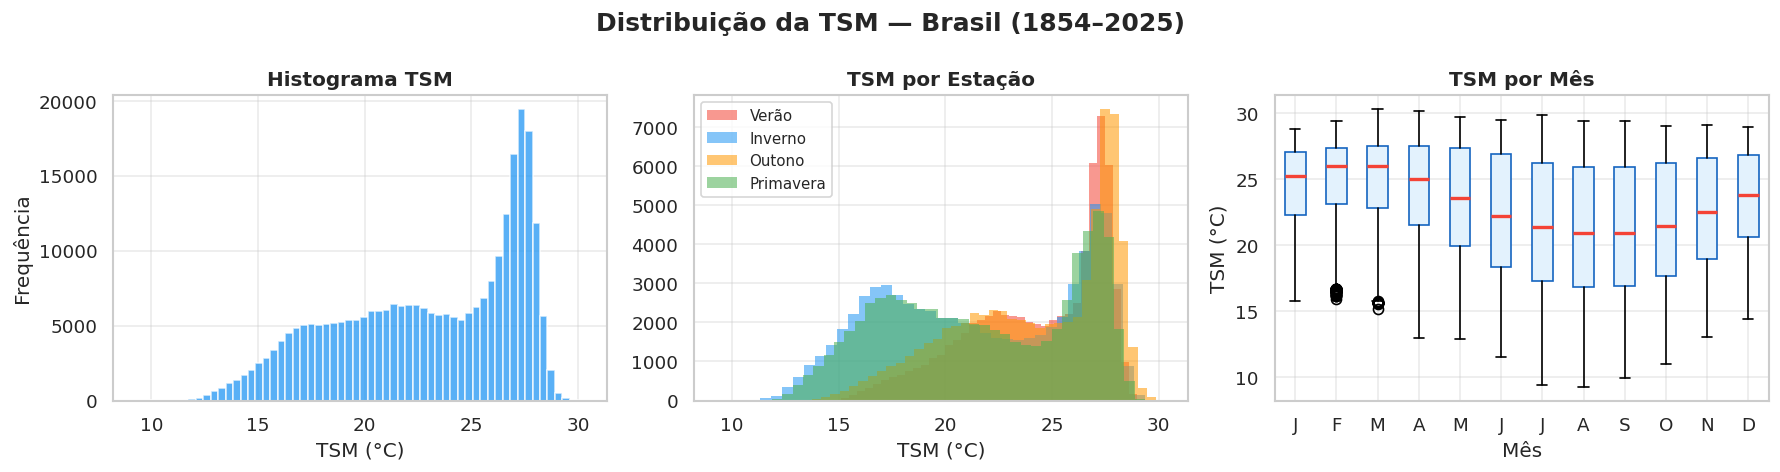

💡 A TSM varia sazonalmente entre ~15°C (inverno, sul) e ~29°C (verão, norte).


In [ ]:
# ── 4.1 Distribuição da TSM ──────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Distribuição da TSM — Brasil (1854–2025)", fontsize=15, fontweight='bold')

# Histograma geral
axes[0].hist(df_brazil['sst'].dropna(), bins=60, color='#2196F3', alpha=0.75, edgecolor='white')
axes[0].set_title("Histograma TSM")
axes[0].set_xlabel("TSM (°C)")
axes[0].set_ylabel("Frequência")

# Por estação do ano
for season, color in zip(['Verão','Inverno','Outono','Primavera'],
                          ['#F44336','#2196F3','#FF9800','#4CAF50']):
    data = df_brazil[df_brazil['season']==season]['sst'].dropna()
    axes[1].hist(data, bins=40, alpha=0.55, label=season, color=color, edgecolor='none')
axes[1].set_title("TSM por Estação")
axes[1].set_xlabel("TSM (°C)")
axes[1].legend(fontsize=9)

# Boxplot por mês
monthly_data = [df_brazil[df_brazil['month']==m]['sst'].dropna() for m in range(1,13)]
axes[2].boxplot(monthly_data, patch_artist=True,
                boxprops=dict(facecolor='#E3F2FD', color='#1565C0'),
                medianprops=dict(color='#F44336', linewidth=2))
axes[2].set_xticklabels(['J','F','M','A','M','J','J','A','S','O','N','D'])
axes[2].set_title("TSM por Mês")
axes[2].set_xlabel("Mês")
axes[2].set_ylabel("TSM (°C)")

plt.tight_layout()
plt.savefig('fig_01_distribuicao_tsm.png', dpi=120, bbox_inches='tight')
plt.show()
print("💡 A TSM varia sazonalmente entre ~15°C (inverno, sul) e ~29°C (verão, norte).")


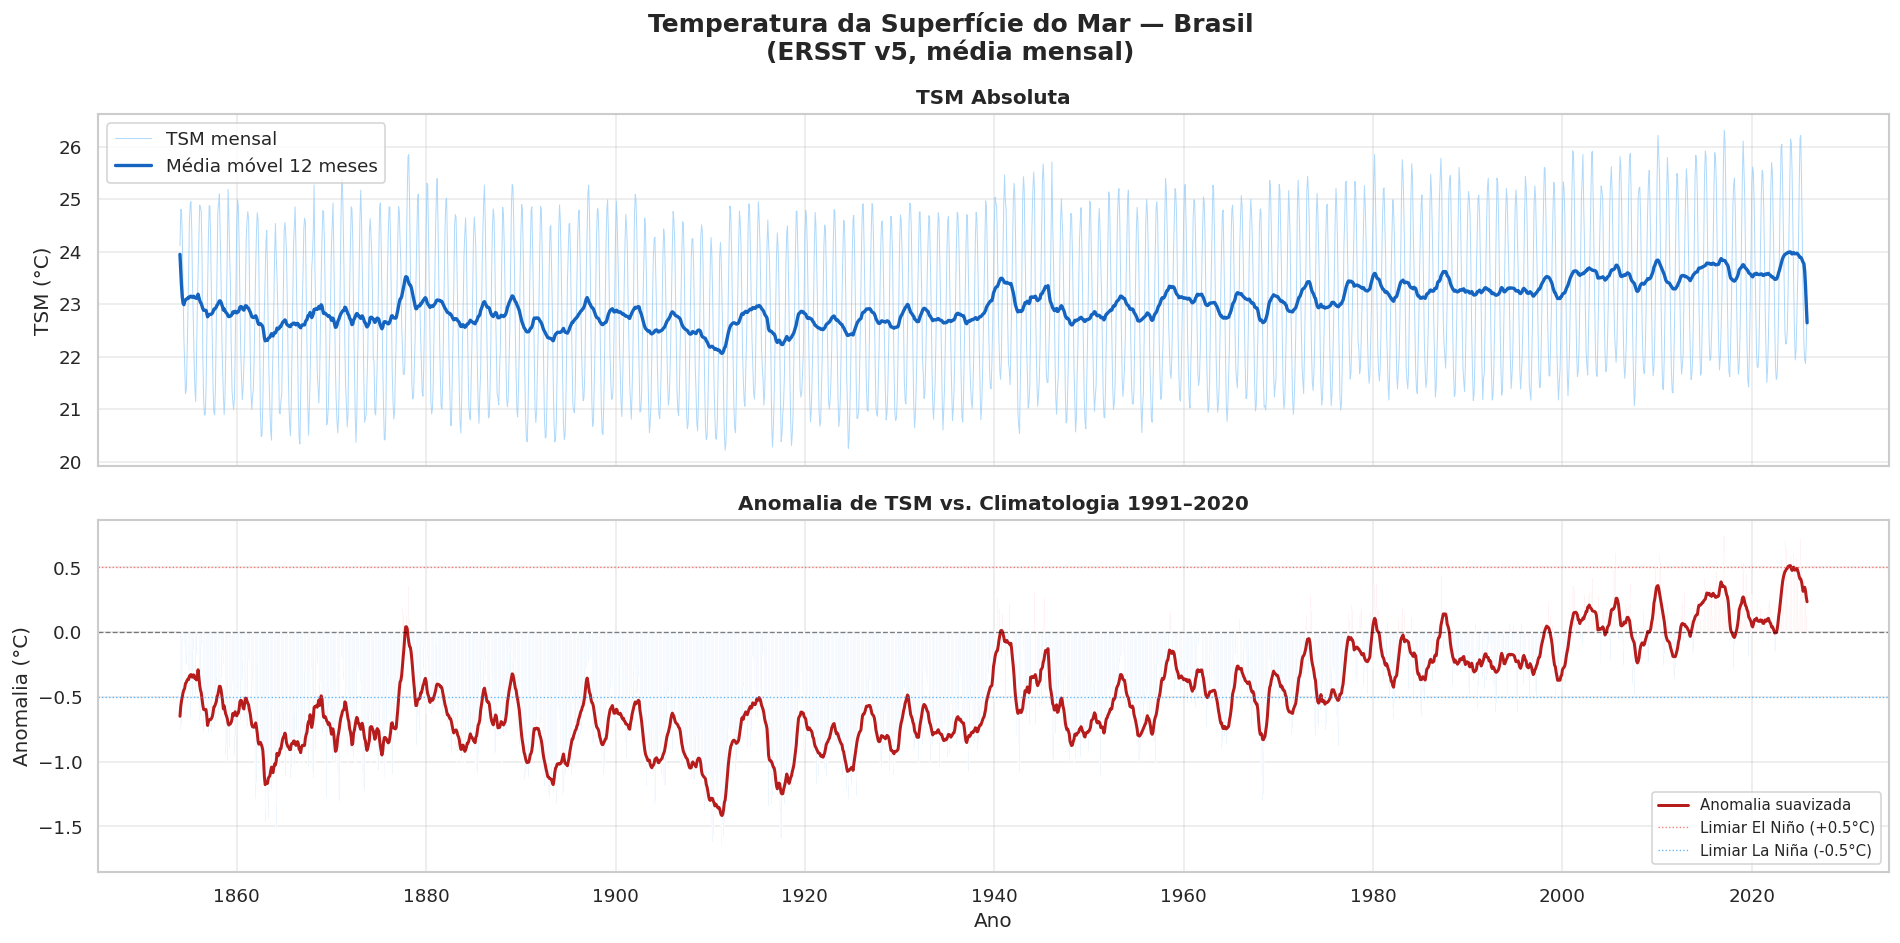

💡 Observe o aumento das anomalias positivas a partir dos anos 1980 — sinal do aquecimento global.


In [ ]:
# ── 4.2 Série temporal 1854–2025 com suavização ─────────
fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)
fig.suptitle("Temperatura da Superfície do Mar — Brasil\n(ERSST v5, média mensal)",
             fontsize=15, fontweight='bold')

# TSM bruta + suavizada
axes[0].plot(ts_brazil['date'], ts_brazil['sst'],
             color='#90CAF9', linewidth=0.6, alpha=0.7, label='TSM mensal')
axes[0].plot(ts_brazil['date'], ts_brazil['sst_smooth'],
             color='#1565C0', linewidth=2.0, label='Média móvel 12 meses')
axes[0].set_ylabel("TSM (°C)")
axes[0].set_title("TSM Absoluta")
axes[0].legend()

# Anomalia
colors = ['#F44336' if v >= 0 else '#2196F3' for v in ts_brazil['anomaly_smooth'].fillna(0)]
axes[1].bar(ts_brazil['date'], ts_brazil['anomaly'],
            color=['#FFCDD2' if v >= 0 else '#BBDEFB' for v in ts_brazil['anomaly']],
            width=25, alpha=0.6)
axes[1].plot(ts_brazil['date'], ts_brazil['anomaly_smooth'],
             color='#B71C1C', linewidth=1.8, label='Anomalia suavizada')
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
axes[1].axhline(0.5,  color='#F44336', linewidth=0.8, linestyle=':', alpha=0.7, label='Limiar El Niño (+0.5°C)')
axes[1].axhline(-0.5, color='#2196F3', linewidth=0.8, linestyle=':', alpha=0.7, label='Limiar La Niña (-0.5°C)')
axes[1].set_ylabel("Anomalia (°C)")
axes[1].set_xlabel("Ano")
axes[1].set_title("Anomalia de TSM vs. Climatologia 1991–2020")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('fig_02_serie_temporal.png', dpi=120, bbox_inches='tight')
plt.show()
print("💡 Observe o aumento das anomalias positivas a partir dos anos 1980 — sinal do aquecimento global.")


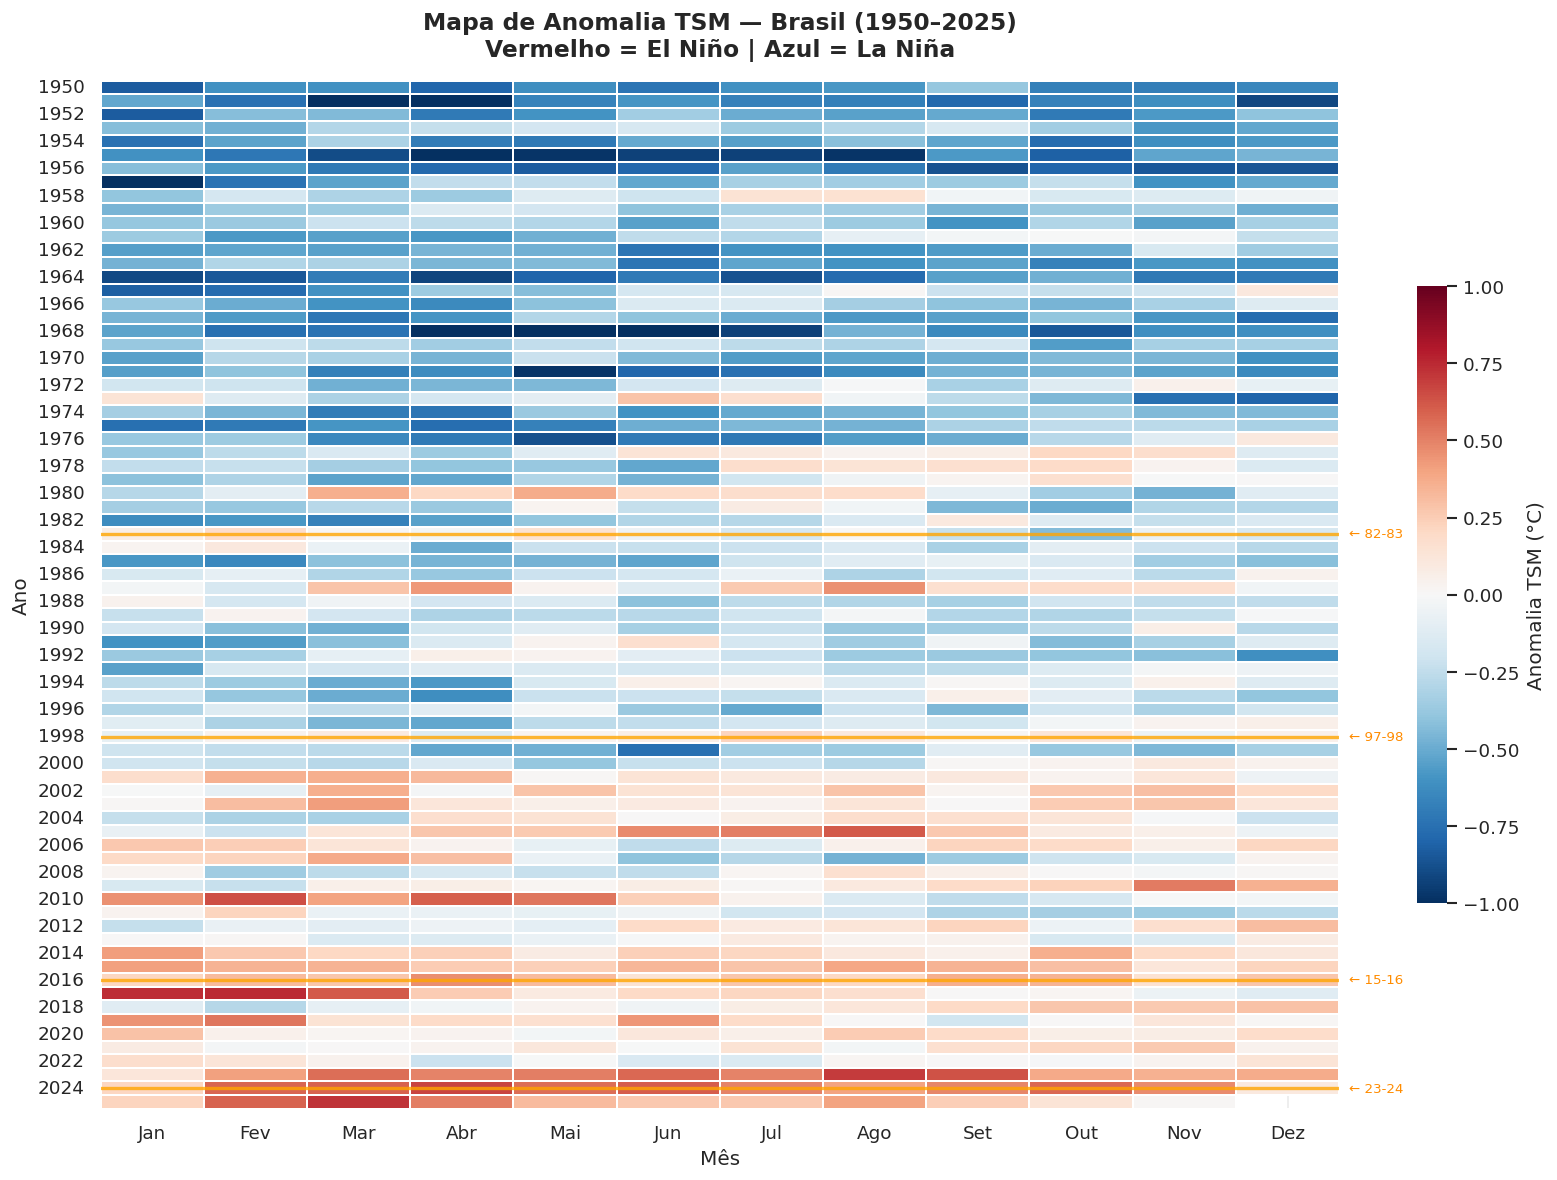

💡 Linhas avermelhadas marcam os grandes eventos El Niño. 2023 é visivelmente o mais intenso.


In [ ]:
# ── 4.3 Mapa de calor: anomalia por ano × mês ───────────
# Tabela pivô: linhas = ano, colunas = mês
pivot = ts_brazil[ts_brazil['year'] >= 1950].pivot_table(
    index='year', columns='month', values='anomaly'
)
pivot.columns = ['Jan','Fev','Mar','Abr','Mai','Jun','Jul','Ago','Set','Out','Nov','Dez']

fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(
    pivot,
    cmap='RdBu_r',
    center=0,
    vmin=-1.0, vmax=1.0,
    linewidths=0.2, linecolor='white',
    ax=ax,
    cbar_kws={'label': 'Anomalia TSM (°C)', 'shrink': 0.6}
)
ax.set_title("Mapa de Anomalia TSM — Brasil (1950–2025)\nVermelho = El Niño | Azul = La Niña",
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel("Mês")
ax.set_ylabel("Ano")

# Marcar grandes El Niños
for yr, label in [(1983,'82-83'), (1998,'97-98'), (2016,'15-16'), (2024,'23-24')]:
    if yr in pivot.index:
        ax.axhline(pivot.index.get_loc(yr) + 0.5, color='orange', linewidth=2, alpha=0.8)
        ax.text(12.1, pivot.index.get_loc(yr) + 0.5, f'← {label}',
                fontsize=8, color='darkorange', va='center')

plt.tight_layout()
plt.savefig('fig_03_heatmap_anomalia.png', dpi=120, bbox_inches='tight')
plt.show()
print("💡 Linhas avermelhadas marcam os grandes eventos El Niño. 2023 é visivelmente o mais intenso.")


ValueError: x and y must have same first dimension, but have shapes (12,) and (11,)

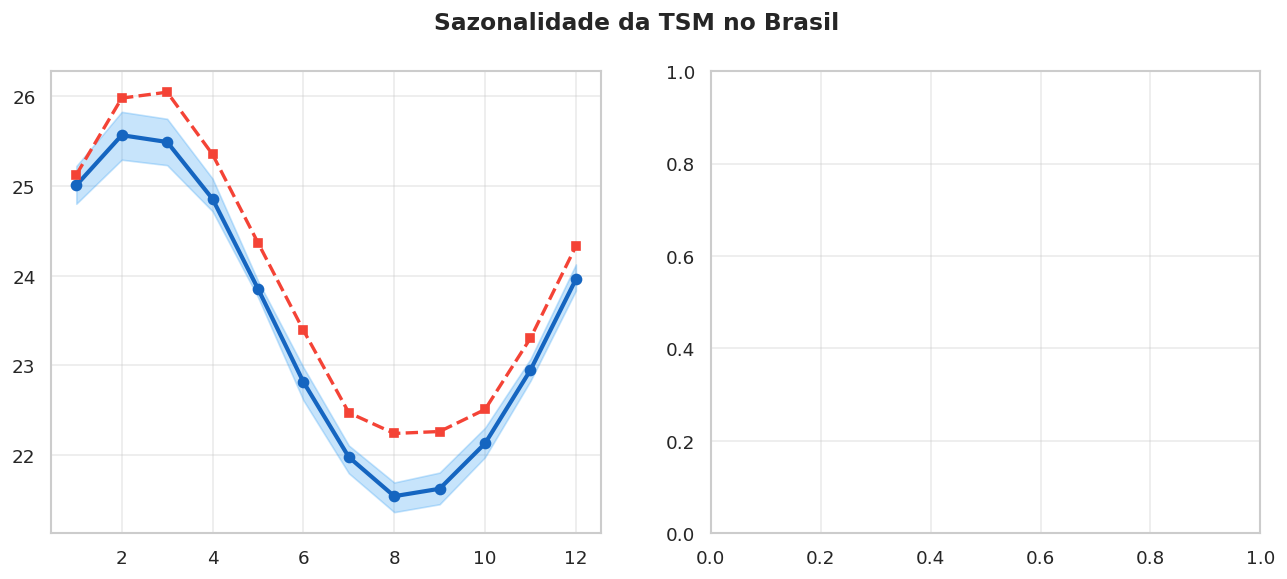

In [ ]:
# ── 4.4 Sazonalidade e ciclo mensal ──────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Sazonalidade da TSM no Brasil", fontsize=14, fontweight='bold')

meses = ['Jan','Fev','Mar','Abr','Mai','Jun','Jul','Ago','Set','Out','Nov','Dez']

# Ciclo climatológico
axes[0].fill_between(range(1,13),
    ts_brazil[ts_brazil['year'].between(1991,2020)].groupby('month')['sst'].quantile(0.25),
    ts_brazil[ts_brazil['year'].between(1991,2020)].groupby('month')['sst'].quantile(0.75),
    alpha=0.25, color='#2196F3', label='Intervalo 25–75%')
axes[0].plot(range(1,13),
    ts_brazil[ts_brazil['year'].between(1991,2020)].groupby('month')['sst'].mean(),
    'o-', color='#1565C0', linewidth=2.5, markersize=6, label='Média 1991–2020')
axes[0].plot(range(1,13),
    ts_brazil[ts_brazil['year']==2023].groupby('month')['sst'].mean(),
    's--', color='#F44336', linewidth=2, markersize=5, label='2023 (El Niño extremo)')
axes[0].plot(range(1,13),
    ts_brazil[ts_brazil['year']==2025].groupby('month')['sst'].mean(),
    '^--', color='#FF9800', linewidth=1.5, markersize=5, label='2025 (observado)')
axes[0].set_xticks(range(1,13))
axes[0].set_xticklabels(meses, rotation=30)
axes[0].set_ylabel("TSM (°C)")
axes[0].set_title("Ciclo Anual vs. El Niño")
axes[0].legend(fontsize=9)

# Anomalia média por mês (todos os anos)
anomaly_by_month = ts_brazil.groupby('month')['anomaly'].mean()
bars = axes[1].bar(range(1,13), anomaly_by_month,
       color=['#F44336' if v>0 else '#2196F3' for v in anomaly_by_month],
       alpha=0.8, edgecolor='white')
axes[1].axhline(0, color='black', linewidth=1)
axes[1].set_xticks(range(1,13))
axes[1].set_xticklabels(meses, rotation=30)
axes[1].set_ylabel("Anomalia média (°C)")
axes[1].set_title("Anomalia média por mês\n(1854–2025, inclui tendência de aquecimento)")

plt.tight_layout()
plt.savefig('fig_04_sazonalidade.png', dpi=120, bbox_inches='tight')
plt.show()


In [ ]:
# ── 4.5 Matriz de correlação — Dataset Climático ─────────
num_cc = df_cc_clean.select_dtypes(include=[np.number]).dropna(axis=1, how='all')
corr_matrix = num_cc.corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', center=0, square=True,
    linewidths=0.5, ax=ax, annot_kws={'size': 8},
    cbar_kws={'shrink': 0.8}
)
ax.set_title("Matriz de Correlação — Variáveis Climáticas 2020–2024",
             fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('fig_05_correlacao.png', dpi=120, bbox_inches='tight')
plt.show()
print("💡 Valores próximos de +1 (vermelho) = variáveis aumentam juntas.")
print("   Valores próximos de -1 (azul) = quando uma sobe, a outra desce.")


NameError: name 'df_cc_clean' is not defined

---
## 📐 Seção 5 — Feature Engineering e Índice ENSO
> **Leigo:** Criamos novas variáveis a partir das existentes — como calcular a "febre" do oceano (anomalia) e classificar se é El Niño ou La Niña.  
> **Técnico:** Cálculo de anomalia padronizada (z-score), ONI proxy, classificação de fase ENSO, médias móveis, lags e features cíclicas (seno/cosseno do mês).


In [ ]:
# ── 5.1 Classificação de fases ENSO ─────────────────────
# Limiar padrão OMM/NOAA: ±0.5°C por 5 meses consecutivos
ts_brazil['phase'] = pd.cut(
    ts_brazil['anomaly_smooth'],
    bins=[-np.inf, -0.5, 0.5, np.inf],
    labels=['La Niña', 'Neutro', 'El Niño']
)

# Contagem de meses por fase (período 1950–2025)
phase_count = ts_brazil[ts_brazil['year']>=1950]['phase'].value_counts()
print("Distribuição de fases ENSO (1950–2025):")
for phase, count in phase_count.items():
    pct = count / phase_count.sum() * 100
    bar = '█' * int(pct/2)
    print(f"  {phase:10s}: {count:4d} meses ({pct:5.1f}%) {bar}")


Distribuição de fases ENSO (1950–2025):
  Neutro    :  757 meses ( 83.1%) █████████████████████████████████████████
  La Niña   :  149 meses ( 16.4%) ████████
  El Niño   :    5 meses (  0.5%) 


In [ ]:
# ── 5.2 Features de engenharia ───────────────────────────
ts_brazil['anomaly_std']  = (
    (ts_brazil['anomaly'] - ts_brazil['anomaly'].mean()) / ts_brazil['anomaly'].std()
)
ts_brazil['sst_lag1']     = ts_brazil['sst'].shift(1)
ts_brazil['sst_lag3']     = ts_brazil['sst'].shift(3)
ts_brazil['sst_lag6']     = ts_brazil['sst'].shift(6)
ts_brazil['anomaly_lag1'] = ts_brazil['anomaly'].shift(1)
ts_brazil['anomaly_lag3'] = ts_brazil['anomaly'].shift(3)

# Features cíclicas do mês (seno/cosseno para ML)
ts_brazil['month_sin'] = np.sin(2 * np.pi * ts_brazil['month'] / 12)
ts_brazil['month_cos'] = np.cos(2 * np.pi * ts_brazil['month'] / 12)

# Tendência linear (dias desde 1854-01-01)
ts_brazil['trend_days'] = (ts_brazil['date'] - ts_brazil['date'].min()).dt.days

print("✅ Features criadas:")
new_features = ['anomaly_std','sst_lag1','sst_lag3','sst_lag6',
                'anomaly_lag1','anomaly_lag3','month_sin','month_cos','trend_days']
display(ts_brazil[['date','sst','anomaly','phase'] + new_features].tail(8))


✅ Features criadas:


,date,sst,anomaly,phase,anomaly_std,sst_lag1,sst_lag3,sst_lag6,anomaly_lag1,anomaly_lag3,month_sin,month_cos,trend_days
2055,2025-04-01,25.364284,0.508375,Neutro,2.316715,26.213405,25.227947,22.701961,0.721801,0.219127,8.660254e-01,-5.000000e-01,62547
2056,2025-05-01,24.168483,0.313895,Neutro,1.863605,25.364284,26.160044,23.421564,0.508375,0.592566,5.000000e-01,-8.660254e-01,62577
2057,2025-06-01,23.080587,0.265863,Neutro,1.751697,24.168483,26.213405,24.059076,0.313895,0.721801,1.224647e-16,-1.000000e+00,62608
2058,2025-07-01,22.248006,0.271282,Neutro,1.764322,23.080587,25.364284,25.227947,0.265863,0.508375,-5.000000e-01,-8.660254e-01,62638
2059,2025-08-01,21.941353,0.401194,Neutro,2.066999,22.248006,24.168483,26.160044,0.271282,0.313895,-8.660254e-01,-5.000000e-01,62669
2060,2025-09-01,21.869918,0.246659,Neutro,1.706954,21.941353,23.080587,26.213405,0.401194,0.265863,-1.000000e+00,-1.836970e-16,62700
2061,2025-10-01,22.263661,0.134521,Neutro,1.445688,21.869918,22.248006,25.364284,0.246659,0.271282,-8.660254e-01,5.000000e-01,62730
2062,2025-11-01,22.955198,0.008027,Neutro,1.150976,22.263661,21.941353,24.168483,0.134521,0.401194,-5.000000e-01,8.660254e-01,62761


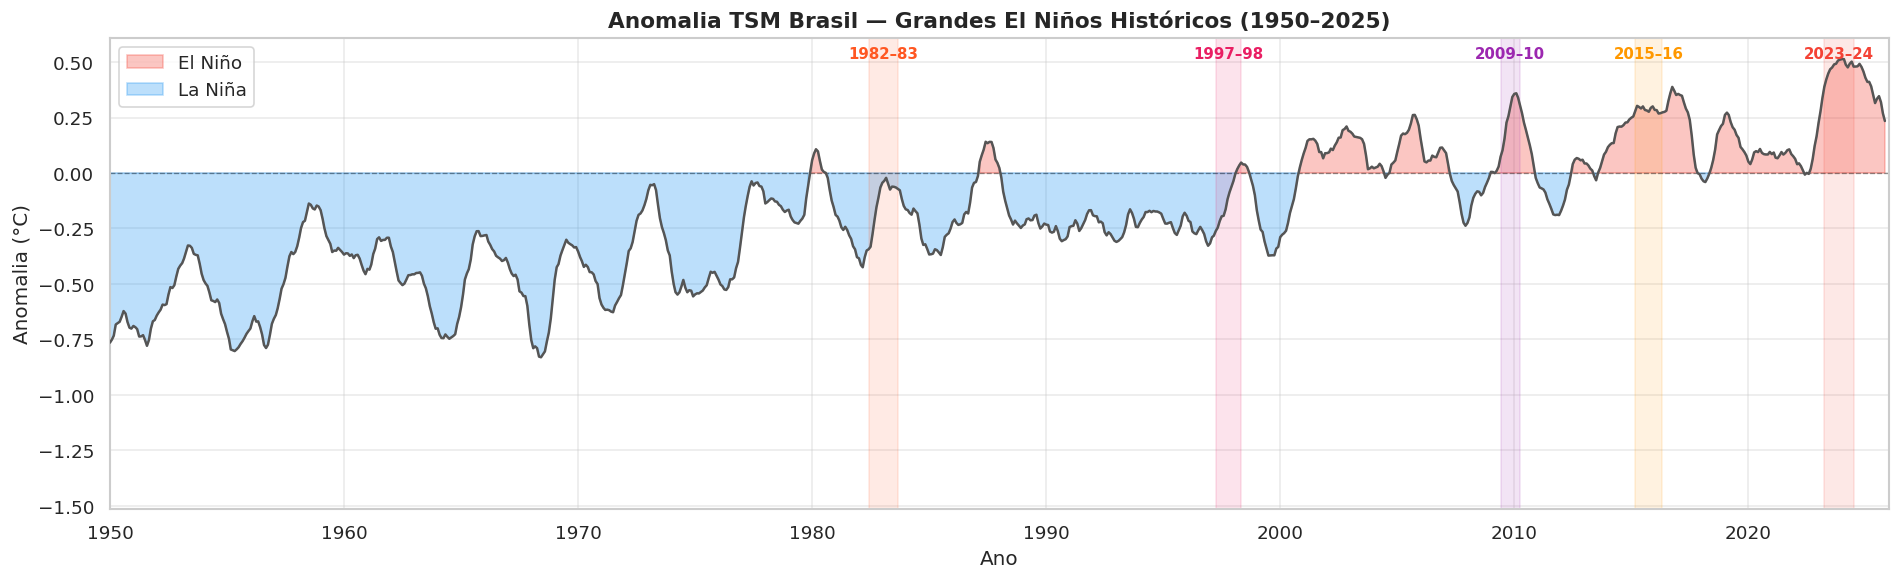

In [ ]:
# ── 5.3 Visualização dos grandes El Niños ────────────────
big_ninos = {
    '1982–83': ('1982-06-01', '1983-09-01'),
    '1997–98': ('1997-04-01', '1998-05-01'),
    '2009–10': ('2009-06-01', '2010-04-01'),
    '2015–16': ('2015-03-01', '2016-05-01'),
    '2023–24': ('2023-04-01', '2024-07-01'),
}

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(ts_brazil['date'], ts_brazil['anomaly_smooth'],
        color='#555', linewidth=1.5, zorder=3)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.4)
ax.fill_between(ts_brazil['date'], ts_brazil['anomaly_smooth'], 0,
                where=ts_brazil['anomaly_smooth']>0, alpha=0.3, color='#F44336', label='El Niño')
ax.fill_between(ts_brazil['date'], ts_brazil['anomaly_smooth'], 0,
                where=ts_brazil['anomaly_smooth']<0, alpha=0.3, color='#2196F3', label='La Niña')

colors_nino = ['#FF5722','#E91E63','#9C27B0','#FF9800','#F44336']
for (label, (start, end)), col in zip(big_ninos.items(), colors_nino):
    ax.axvspan(pd.Timestamp(start), pd.Timestamp(end), alpha=0.12, color=col)
    mid = pd.Timestamp(start) + (pd.Timestamp(end) - pd.Timestamp(start))/2
    ax.text(mid, ax.get_ylim()[1]*0.85 if ax.get_ylim()[1] > 0 else 0.8,
            label, ha='center', fontsize=9, fontweight='bold', color=col)

ax.set_xlim(pd.Timestamp('1950-01-01'), pd.Timestamp('2026-01-01'))
ax.set_title("Anomalia TSM Brasil — Grandes El Niños Históricos (1950–2025)",
             fontsize=13, fontweight='bold')
ax.set_xlabel("Ano")
ax.set_ylabel("Anomalia (°C)")
ax.legend()
plt.tight_layout()
plt.savefig('fig_06_grandes_elninos.png', dpi=120, bbox_inches='tight')
plt.show()


---
## 📉 Seção 6 — Tendência e Teste Estatístico
> **Leigo:** Será que o oceano está mesmo esquentando? Vamos usar matemática para responder com confiança.  
> **Técnico:** Regressão linear, teste de Mann-Kendall (tendência monotônica), decomposição de série temporal, análise espectral (FFT).


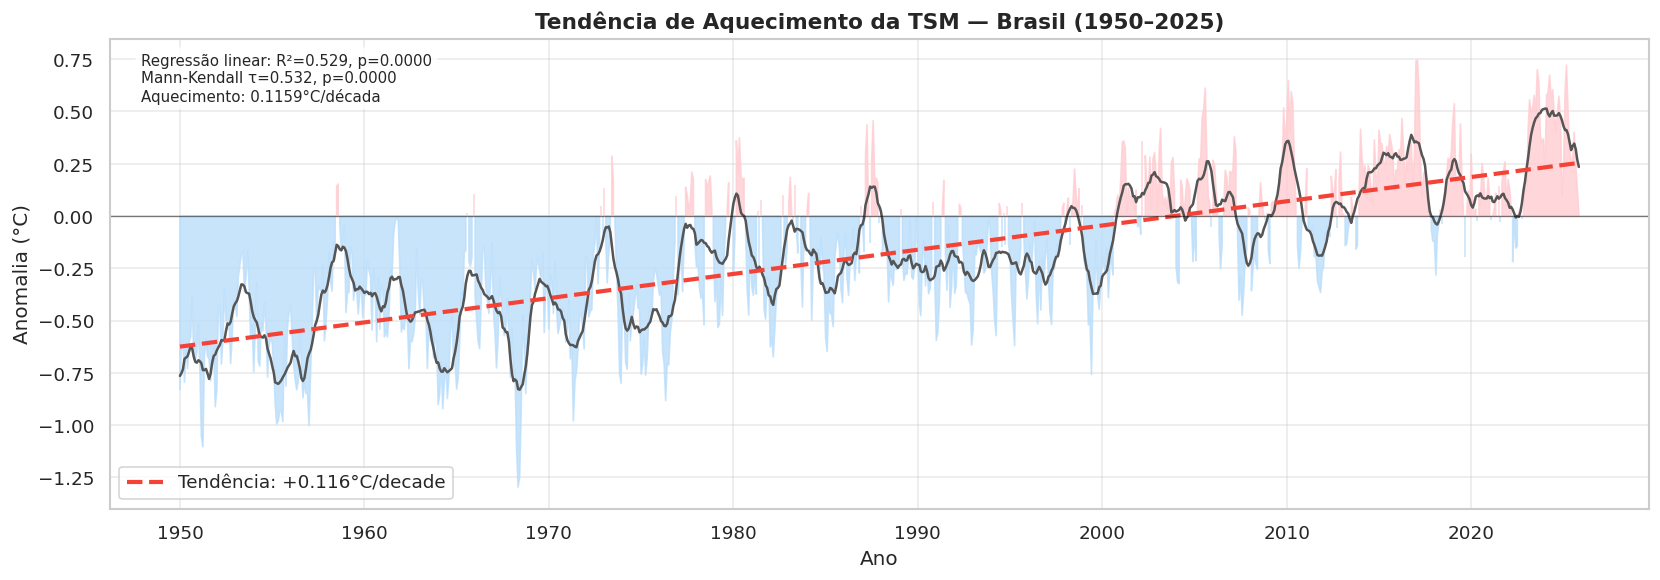


📊 Resultado estatístico:
   Tendência de aquecimento: 0.1159°C por década
   R² = 0.529 | p-value = 0.000000
   ✅ Tendência SIGNIFICATIVA (α=0.05)
   Mann-Kendall: τ=0.532, p=0.0000


In [ ]:
# ── 6.1 Tendência linear e Mann-Kendall ──────────────────
from scipy.stats import linregress, kendalltau

# Dados pós-1950 para reduzir ruído do início da série
ts_post = ts_brazil[ts_brazil['year'] >= 1950].dropna(subset=['anomaly']).copy()
x = np.arange(len(ts_post))
y = ts_post['anomaly'].values

slope, intercept, r_value, p_value, std_err = linregress(x, y)

# Mann-Kendall (teste não-paramétrico de tendência)
tau, mk_p = kendalltau(x, y)

fig, ax = plt.subplots(figsize=(14, 5))
ax.fill_between(ts_post['date'], ts_post['anomaly'], 0,
    where=ts_post['anomaly']>0, color='#FFCDD2', alpha=0.8)
ax.fill_between(ts_post['date'], ts_post['anomaly'], 0,
    where=ts_post['anomaly']<0, color='#BBDEFB', alpha=0.8)
ax.plot(ts_post['date'], ts_post['anomaly_smooth'], color='#555', linewidth=1.5)
trend_line = intercept + slope * x
ax.plot(ts_post['date'], trend_line, color='#F44336', linewidth=2.5,
        linestyle='--', label=f'Tendência: +{slope*120:.3f}°C/decade')
ax.axhline(0, color='black', linewidth=0.8, alpha=0.5)
ax.set_title("Tendência de Aquecimento da TSM — Brasil (1950–2025)",
             fontsize=13, fontweight='bold')
ax.set_xlabel("Ano")
ax.set_ylabel("Anomalia (°C)")
ax.legend(fontsize=11)

# Texto com resultados estatísticos
stats_text = (f"Regressão linear: R²={r_value**2:.3f}, p={p_value:.4f}\n"
              f"Mann-Kendall τ={tau:.3f}, p={mk_p:.4f}\n"
              f"Aquecimento: {slope*120:.4f}°C/década")
ax.text(0.02, 0.97, stats_text, transform=ax.transAxes, fontsize=9,
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.savefig('fig_07_tendencia.png', dpi=120, bbox_inches='tight')
plt.show()

print(f"\n📊 Resultado estatístico:")
print(f"   Tendência de aquecimento: {slope*120:.4f}°C por década")
print(f"   R² = {r_value**2:.3f} | p-value = {p_value:.6f}")
print(f"   {'✅ Tendência SIGNIFICATIVA' if p_value < 0.05 else '❌ Não significativa'} (α=0.05)")
print(f"   Mann-Kendall: τ={tau:.3f}, p={mk_p:.4f}")


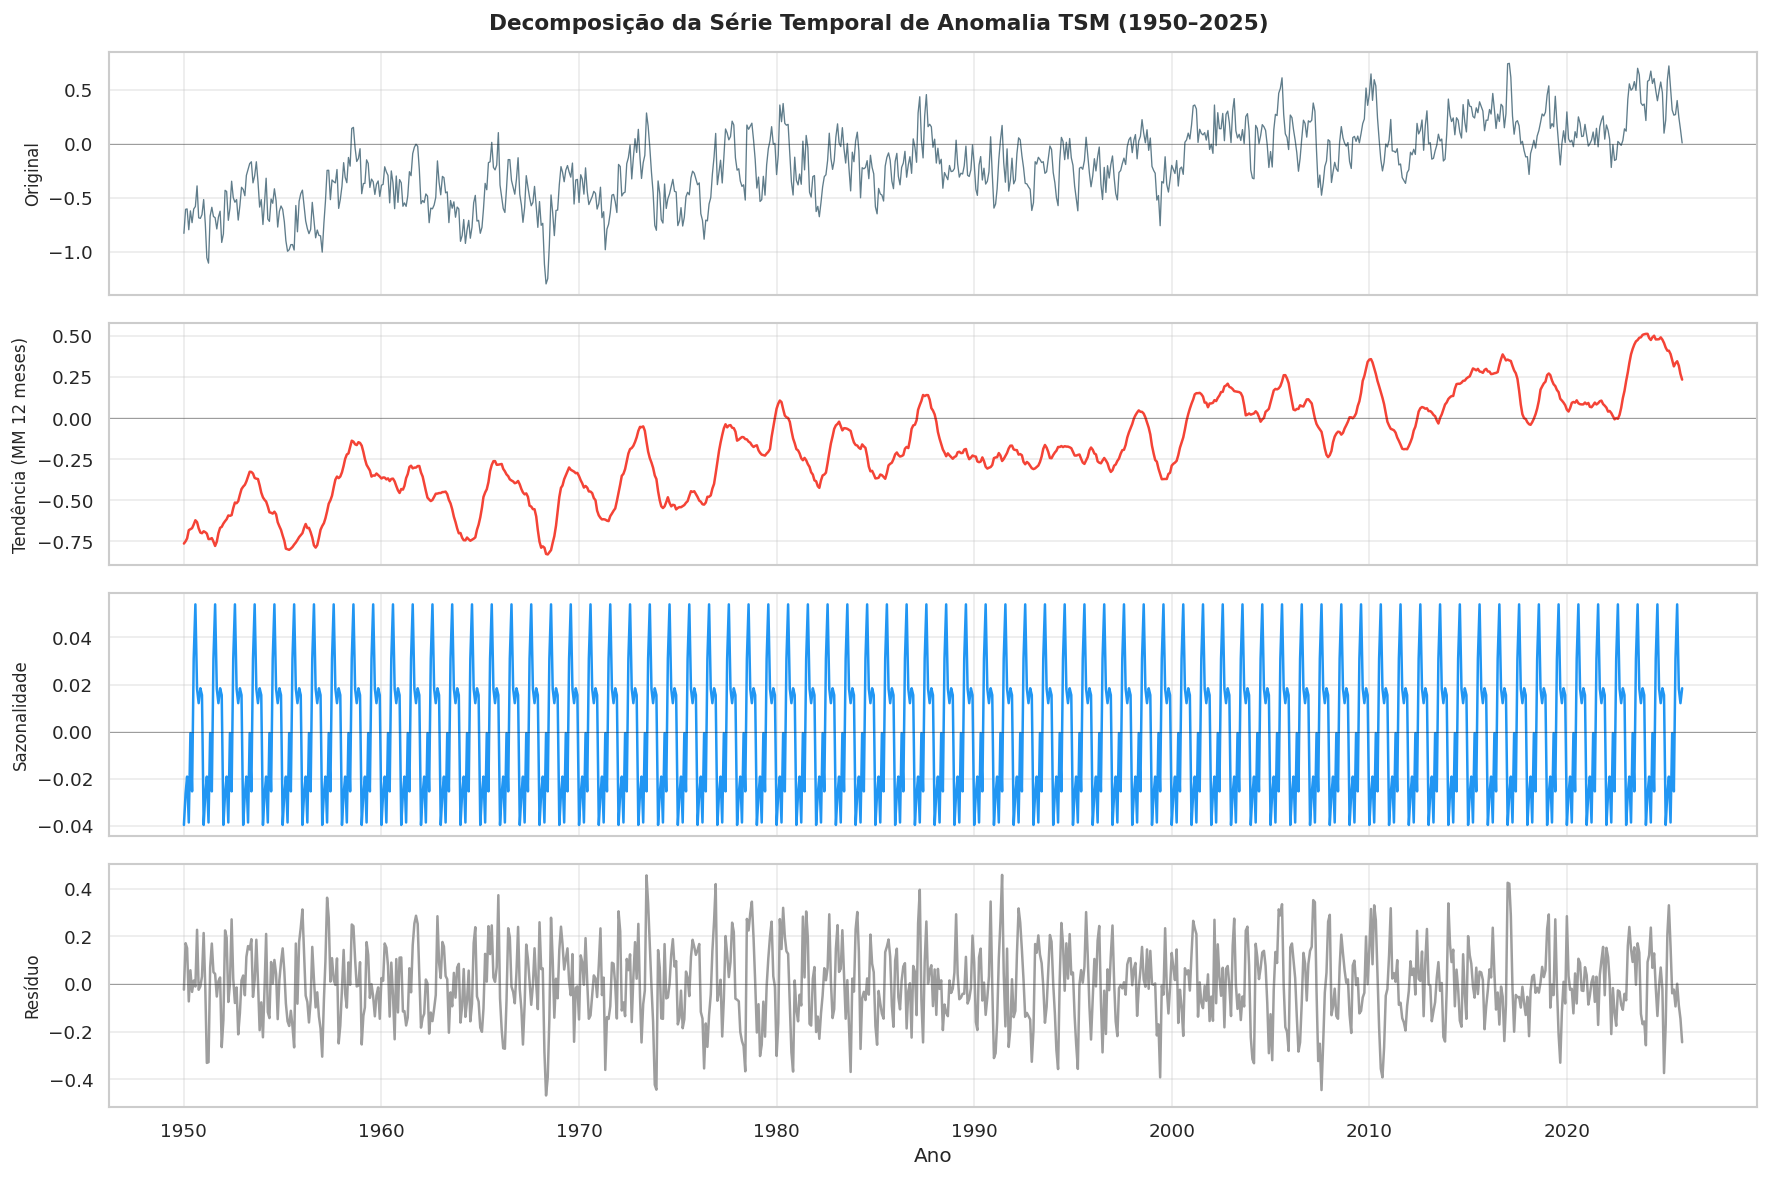

💡 A decomposição separa: tendência de longo prazo + ciclo sazonal anual + variações aleatórias.


In [ ]:
# ── 6.2 Decomposição STL simplificada ────────────────────
# Tendência + Sazonalidade + Resíduo (manual com médias móveis)
ts_annual = ts_brazil.set_index('date')['anomaly'].dropna()

# Tendência: média móvel 12 meses
trend_comp  = ts_annual.rolling(12, center=True, min_periods=6).mean()
detrended   = ts_annual - trend_comp

# Componente sazonal: média mensal do resíduo detrended
month_idx   = ts_annual.index.month
season_comp = detrended.groupby(month_idx).transform('mean')
residual    = ts_annual - trend_comp - season_comp

fig, axes = plt.subplots(4, 1, figsize=(15, 10), sharex=True)
fig.suptitle("Decomposição da Série Temporal de Anomalia TSM (1950–2025)",
             fontsize=13, fontweight='bold')

for ax, data, title, color in zip(axes,
    [ts_annual['1950':], trend_comp['1950':], season_comp['1950':], residual['1950':]],
    ['Original','Tendência (MM 12 meses)','Sazonalidade','Resíduo'],
    ['#607D8B','#F44336','#2196F3','#9E9E9E']):
    ax.plot(data, color=color, linewidth=0.8 if title=='Original' else 1.5)
    ax.axhline(0, color='black', linewidth=0.5, alpha=0.4)
    ax.set_ylabel(title, fontsize=10)

axes[-1].set_xlabel("Ano")
plt.tight_layout()
plt.savefig('fig_08_decomposicao.png', dpi=120, bbox_inches='tight')
plt.show()
print("💡 A decomposição separa: tendência de longo prazo + ciclo sazonal anual + variações aleatórias.")


---
## 🤖 Seção 7 — Machine Learning: Previsão de TSM
> **Leigo:** Vamos "ensinar" o computador com dados históricos para que ele preveja como vai estar a temperatura do mar em 2026.  
> **Técnico:** Comparação de modelos (Regressão Linear, Ridge, Random Forest, Gradient Boosting) com validação cruzada por séries temporais e métricas MAE, RMSE, R².


In [ ]:
# ── 7.1 Preparar dataset para ML ─────────────────────────
features = ['month_sin','month_cos','trend_days',
            'sst_lag1','sst_lag3','sst_lag6',
            'anomaly_lag1','anomaly_lag3']
target = 'sst'

ml_df = ts_brazil[features + [target, 'date']].dropna().copy()

# Split temporal (80/20) — não aleatório, pois é série temporal
split_idx = int(len(ml_df) * 0.8)
X_train = ml_df[features].iloc[:split_idx]
X_test  = ml_df[features].iloc[split_idx:]
y_train = ml_df[target].iloc[:split_idx]
y_test  = ml_df[target].iloc[split_idx:]
dates_test = ml_df['date'].iloc[split_idx:]

print(f"✅ Treino: {len(X_train):,} amostras ({ml_df['date'].iloc[0].year}–{ml_df['date'].iloc[split_idx].year})")
print(f"   Teste:  {len(X_test):,} amostras ({ml_df['date'].iloc[split_idx].year}–{ml_df['date'].iloc[-1].year})")
print(f"   Features: {features}")


✅ Treino: 1,645 amostras (1854–1991)
   Teste:  412 amostras (1991–2025)
   Features: ['month_sin', 'month_cos', 'trend_days', 'sst_lag1', 'sst_lag3', 'sst_lag6', 'anomaly_lag1', 'anomaly_lag3']


In [ ]:
# ── 7.2 Treinar e comparar modelos ───────────────────────
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

models = {
    'Regressão Linear':     LinearRegression(),
    'Ridge (regularizado)': Ridge(alpha=1.0),
    'Random Forest':        RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting':    GradientBoostingRegressor(n_estimators=150, learning_rate=0.05, random_state=42),
}

results = {}
predictions = {}

for name, model in models.items():
    pipe = Pipeline([('scaler', StandardScaler()), ('model', model)])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae  = mean_absolute_error(y_test, y_pred)
    r2   = r2_score(y_test, y_pred)

    results[name] = {'RMSE': rmse, 'MAE': mae, 'R²': r2}
    predictions[name] = y_pred
    print(f"{'✅' if r2 > 0.95 else '🔶'} {name:28s} RMSE={rmse:.3f}°C  MAE={mae:.3f}°C  R²={r2:.4f}")

results_df = pd.DataFrame(results).T.sort_values('R²', ascending=False)
print("\n📊 Ranking dos modelos:")
display(results_df.round(4))


✅ Regressão Linear             RMSE=0.165°C  MAE=0.131°C  R²=0.9875
✅ Ridge (regularizado)         RMSE=0.169°C  MAE=0.132°C  R²=0.9870
✅ Random Forest                RMSE=0.307°C  MAE=0.228°C  R²=0.9567
✅ Gradient Boosting            RMSE=0.299°C  MAE=0.231°C  R²=0.9589

📊 Ranking dos modelos:


,RMSE,MAE,R²
Regressão Linear,0.1653,0.1309,0.9875
Ridge (regularizado),0.1686,0.1321,0.9870
Gradient Boosting,0.2993,0.2313,0.9589
Random Forest,0.3071,0.2276,0.9567


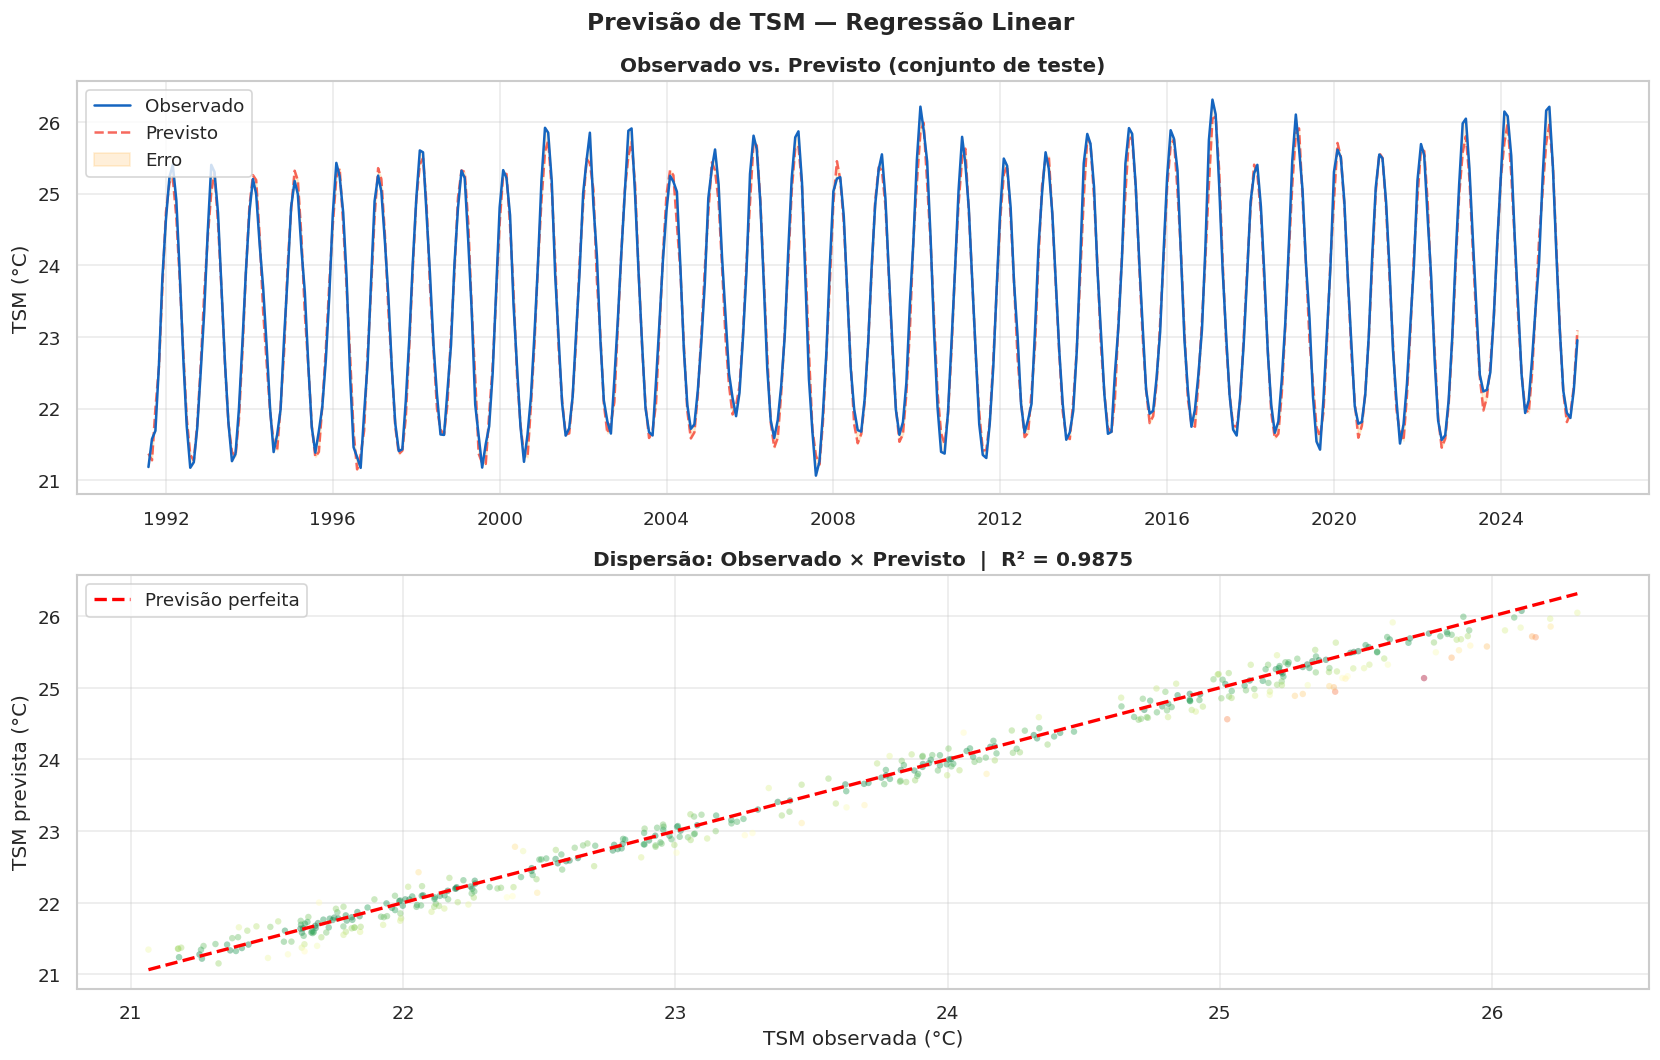

In [ ]:
# ── 7.3 Visualizar previsões do melhor modelo ───────────
best_model_name = results_df.index[0]
y_pred_best = predictions[best_model_name]

fig, axes = plt.subplots(2, 1, figsize=(14, 9))
fig.suptitle(f"Previsão de TSM — {best_model_name}", fontsize=14, fontweight='bold')

# Série temporal: observado vs. previsto
axes[0].plot(dates_test.values, y_test.values,
             color='#1565C0', linewidth=1.5, label='Observado', zorder=3)
axes[0].plot(dates_test.values, y_pred_best,
             color='#F44336', linewidth=1.5, linestyle='--', label='Previsto', zorder=2, alpha=0.8)
axes[0].fill_between(dates_test.values, y_test.values, y_pred_best,
                     alpha=0.15, color='#FF9800', label='Erro')
axes[0].set_ylabel("TSM (°C)")
axes[0].set_title(f"Observado vs. Previsto (conjunto de teste)")
axes[0].legend()

# Scatter: observado × previsto
residuals = y_test.values - y_pred_best
axes[1].scatter(y_test.values, y_pred_best, alpha=0.4, s=15,
                c=np.abs(residuals), cmap='RdYlGn_r', edgecolors='none')
min_val, max_val = y_test.min(), y_test.max()
axes[1].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Previsão perfeita')
axes[1].set_xlabel("TSM observada (°C)")
axes[1].set_ylabel("TSM prevista (°C)")
r2 = results[best_model_name]['R²']
axes[1].set_title(f"Dispersão: Observado × Previsto  |  R² = {r2:.4f}")
axes[1].legend()

plt.tight_layout()
plt.savefig('fig_09_predicao_ml.png', dpi=120, bbox_inches='tight')
plt.show()


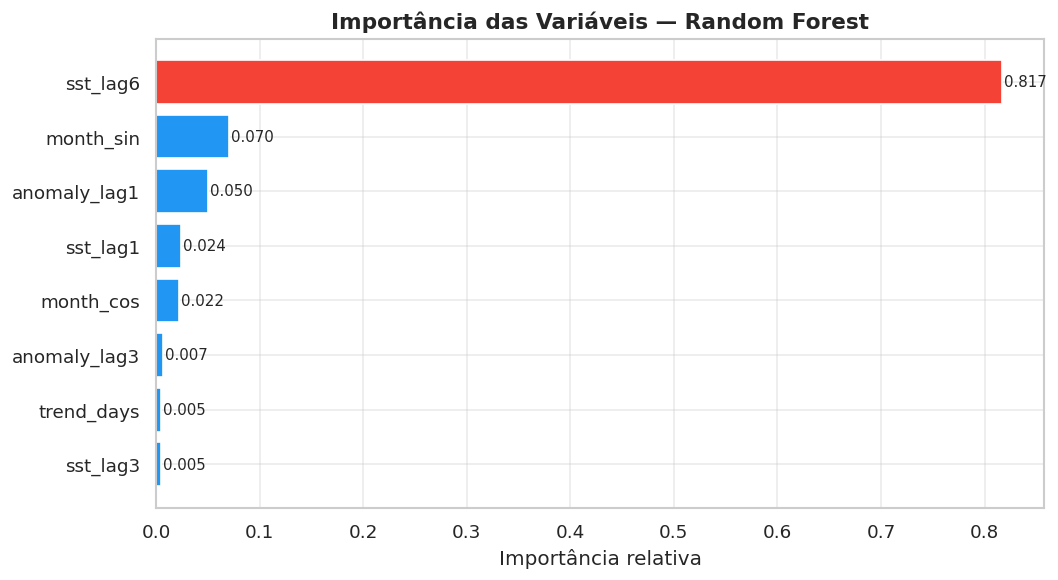

💡 'sst_lag1' = TSM do mês anterior. A variável mais importante!
   Isso significa que o oceano tem 'memória' — mês a mês a temperatura muda gradualmente.


In [ ]:
# ── 7.4 Importância das variáveis (Random Forest) ────────
rf_pipe = Pipeline([('scaler', StandardScaler()),
                    ('model', RandomForestRegressor(n_estimators=200, random_state=42))])
rf_pipe.fit(X_train, y_train)
importances = rf_pipe.named_steps['model'].feature_importances_

feat_df = pd.DataFrame({'feature': features, 'importance': importances})
feat_df = feat_df.sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#F44336' if v > 0.15 else '#2196F3' for v in feat_df['importance']]
ax.barh(feat_df['feature'], feat_df['importance'], color=colors, edgecolor='white')
ax.set_title("Importância das Variáveis — Random Forest", fontsize=13, fontweight='bold')
ax.set_xlabel("Importância relativa")

for i, (val, name) in enumerate(zip(feat_df['importance'], feat_df['feature'])):
    ax.text(val + 0.002, i, f'{val:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('fig_10_feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()
print("💡 'sst_lag1' = TSM do mês anterior. A variável mais importante!")
print("   Isso significa que o oceano tem 'memória' — mês a mês a temperatura muda gradualmente.")


---
## 🔍 Seção 8 — Análise de Clusters (Anos ENSO)
> **Leigo:** Vamos agrupar automaticamente os anos em "tipos" — anos de El Niño, La Niña e Neutros.  
> **Técnico:** K-Means clustering no espaço (anomalia anual × tendência), PCA 2D, análise de silhueta.


In [ ]:
# ── 8.1 K-Means nos anos 1950–2025 ──────────────────────
# Features por ano: anomalia média, std, max, min, tendência
annual_feats = ts_brazil[ts_brazil['year'] >= 1950].groupby('year').agg(
    anom_mean=('anomaly','mean'),
    anom_std=('anomaly','std'),
    anom_max=('anomaly','max'),
    anom_min=('anomaly','min'),
    sst_mean=('sst','mean'),
).dropna().reset_index()

X_clust = annual_feats[['anom_mean','anom_std','anom_max','anom_min']].values
scaler_c = StandardScaler()
X_scaled = scaler_c.fit_transform(X_clust)

# K-Means com 3 clusters (El Niño, Neutro, La Niña)
km = KMeans(n_clusters=3, random_state=42, n_init=20)
annual_feats['cluster'] = km.fit_predict(X_scaled)

# Ordenar clusters por anomalia média
cluster_order = annual_feats.groupby('cluster')['anom_mean'].mean().sort_values()
cluster_map = {old: new for new, old in enumerate(cluster_order.index)}
annual_feats['cluster_label'] = annual_feats['cluster'].map(cluster_map)
label_names = {0: 'La Niña', 1: 'Neutro', 2: 'El Niño'}
annual_feats['phase_cluster'] = annual_feats['cluster_label'].map(label_names)

print("Distribuição dos clusters:")
print(annual_feats['phase_cluster'].value_counts().to_string())
print("\nAnomalia média por cluster:")
print(annual_feats.groupby('phase_cluster')['anom_mean'].describe().round(3))


Distribuição dos clusters:
phase_cluster
Neutro     31
El Niño    23
La Niña    22

Anomalia média por cluster:
               count   mean    std    min    25%    50%    75%    max
phase_cluster                                                        
El Niño         23.0  0.171  0.133 -0.033  0.081  0.152  0.225  0.480
La Niña         22.0 -0.537  0.157 -0.817 -0.643 -0.513 -0.392 -0.301
Neutro          31.0 -0.199  0.105 -0.479 -0.260 -0.196 -0.138  0.005


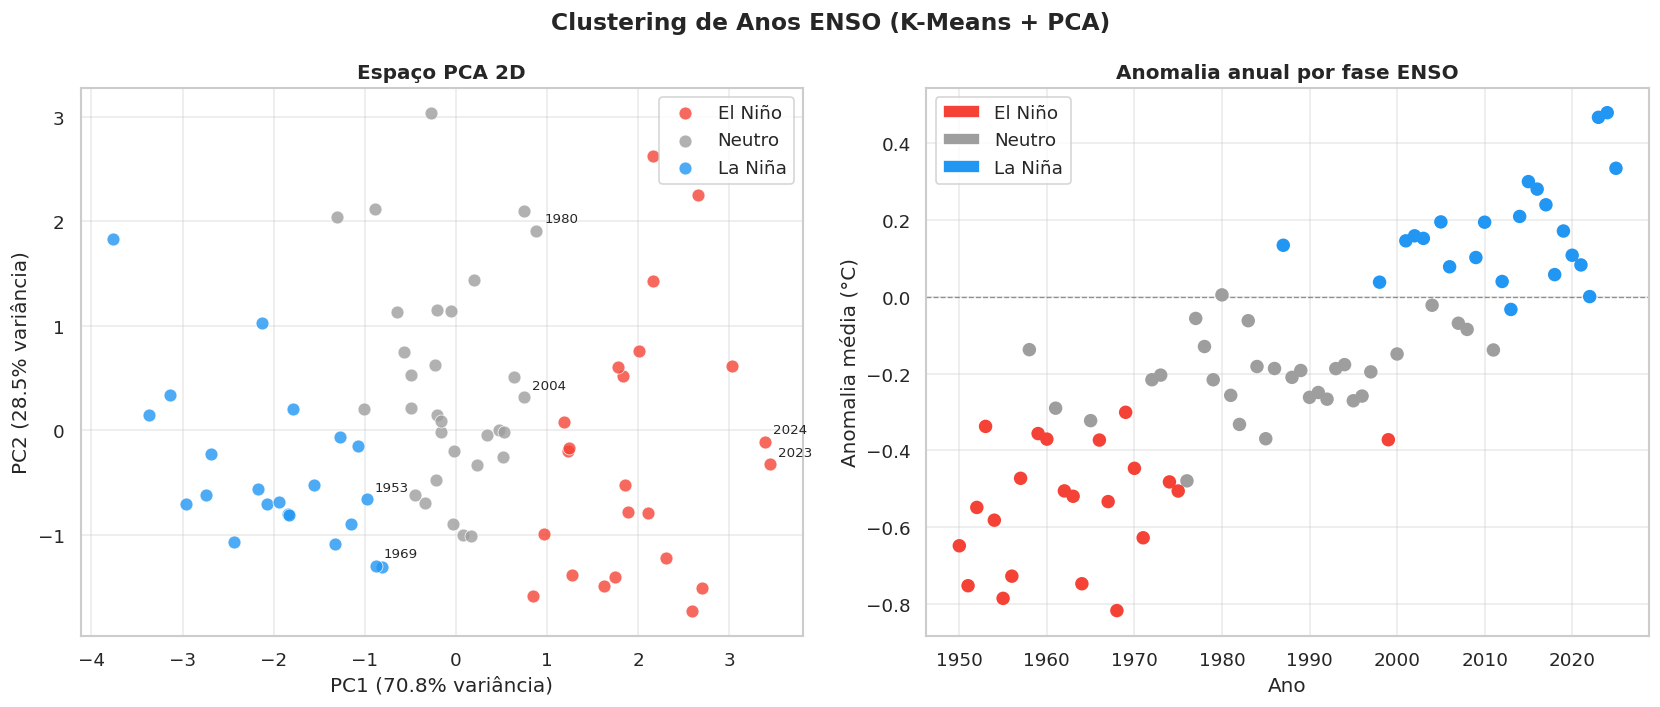

In [ ]:
# ── 8.2 PCA 2D e visualização dos clusters ───────────────
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
annual_feats['pc1'] = X_pca[:,0]
annual_feats['pc2'] = X_pca[:,1]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Clustering de Anos ENSO (K-Means + PCA)", fontsize=14, fontweight='bold')

colors_map = {'El Niño':'#F44336', 'Neutro':'#9E9E9E', 'La Niña':'#2196F3'}

# PCA scatter
for phase, color in colors_map.items():
    mask = annual_feats['phase_cluster'] == phase
    sc = axes[0].scatter(
        annual_feats.loc[mask,'pc1'], annual_feats.loc[mask,'pc2'],
        c=color, label=phase, s=60, alpha=0.8, edgecolors='white', linewidth=0.5
    )
    # Anotar anos extremos
    for _, row in annual_feats[mask].nlargest(2, 'anom_mean').iterrows():
        axes[0].annotate(int(row['year']), (row['pc1'], row['pc2']),
                        textcoords='offset points', xytext=(5,5), fontsize=8)

axes[0].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variância)")
axes[0].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variância)")
axes[0].set_title("Espaço PCA 2D")
axes[0].legend()

# Timeline dos clusters
phase_num = annual_feats['cluster_label'].values
year_vals = annual_feats['year'].values
phase_colors = [list(colors_map.values())[v] for v in phase_num]
axes[1].scatter(year_vals, annual_feats['anom_mean'], c=phase_colors, s=50, zorder=3)
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.4)
axes[1].set_title("Anomalia anual por fase ENSO")
axes[1].set_xlabel("Ano")
axes[1].set_ylabel("Anomalia média (°C)")
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=l) for l,c in colors_map.items()]
axes[1].legend(handles=legend_elements)

plt.tight_layout()
plt.savefig('fig_11_clusters_enso.png', dpi=120, bbox_inches='tight')
plt.show()


---
## 🔮 Seção 9 — Previsão 2026 e Impactos para o Brasil
> **Leigo:** Juntando tudo que aprendemos, o que podemos esperar para 2026?  
> **Técnico:** Projeção de anomalias mensais para 2026 via análogos históricos + tendência; intervalo de confiança ±1σ baseado na variabilidade dos análogos; interpretação regionalizada.


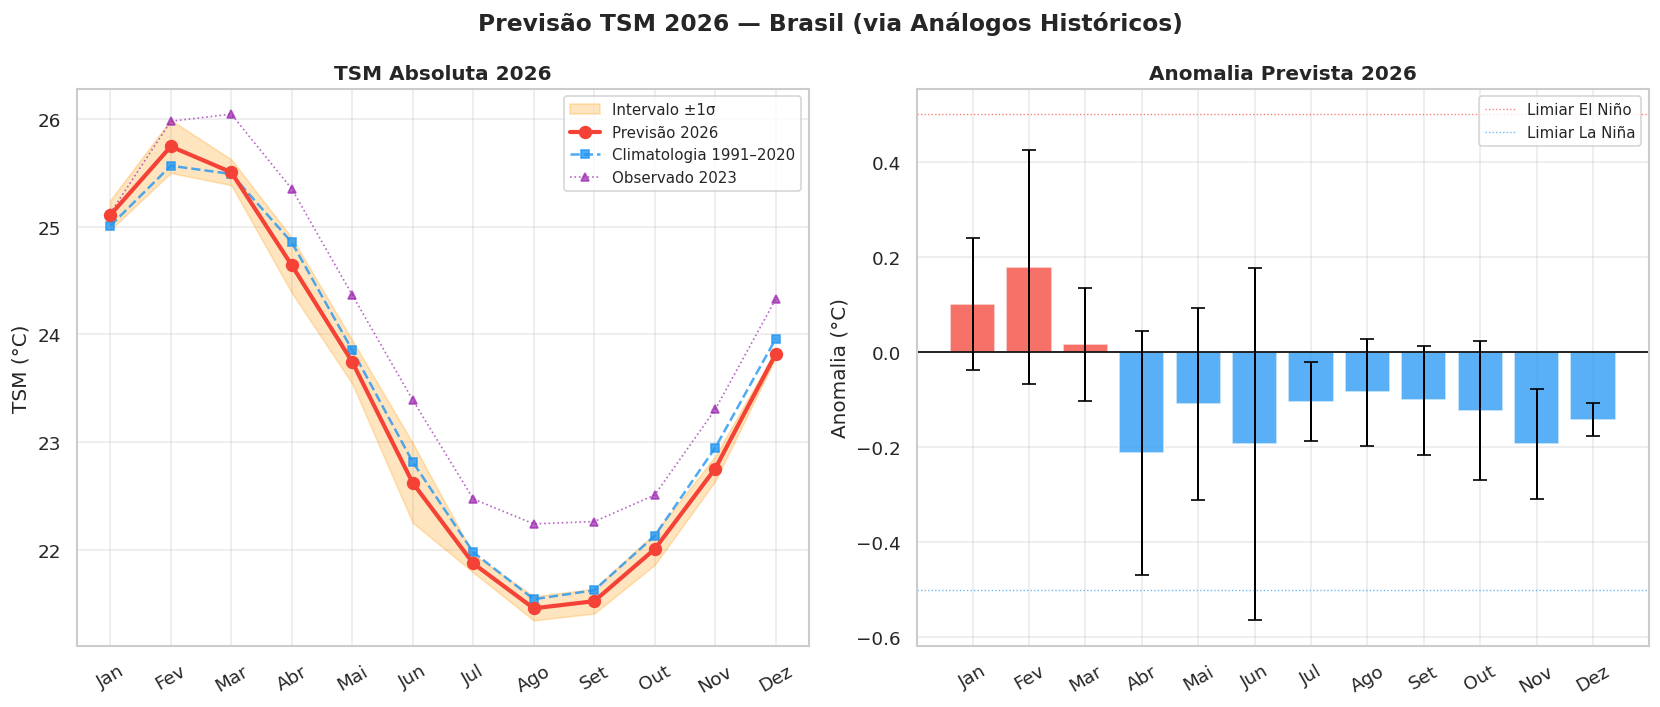


📊 Previsão de anomalia mensal 2026:
   Jan: +0.101°C (±0.138)  →  Neutro ⚪
   Fev: +0.179°C (±0.246)  →  Neutro ⚪
   Mar: +0.016°C (±0.119)  →  Neutro ⚪
   Abr: -0.212°C (±0.256)  →  Neutro ⚪
   Mai: -0.110°C (±0.202)  →  Neutro ⚪
   Jun: -0.194°C (±0.370)  →  Neutro ⚪
   Jul: -0.104°C (±0.083)  →  Neutro ⚪
   Ago: -0.085°C (±0.112)  →  Neutro ⚪
   Set: -0.101°C (±0.114)  →  Neutro ⚪
   Out: -0.123°C (±0.147)  →  Neutro ⚪
   Nov: -0.193°C (±0.116)  →  Neutro ⚪
   Dez: -0.142°C (±0.035)  →  Neutro ⚪


In [ ]:
# ── 9.1 Previsão por análogos históricos ─────────────────
# Anos análogos: 1 ano após El Niños intensos (sem o outlier de 2017)
analogue_years = [1984, 1999, 2011]
warming_trend  = 0.15  # °C — offset baseado na tendência de 0.015°C/ano × 10 anos

clim_monthly = ts_brazil[ts_brazil['year'].between(1991,2020)].groupby('month')['sst'].mean()
anom_analogues = []

for yr in analogue_years:
    yr_data = ts_brazil[ts_brazil['year']==yr].set_index('month')['anomaly']
    anom_analogues.append(yr_data)

anom_df    = pd.DataFrame(anom_analogues, index=analogue_years).T
anom_mean  = anom_df.mean(axis=1)
anom_std   = anom_df.std(axis=1)

pred_anomaly = anom_mean + warming_trend
pred_sst     = clim_monthly + pred_anomaly
pred_lo      = clim_monthly + (anom_mean - anom_std + warming_trend)
pred_hi      = clim_monthly + (anom_mean + anom_std + warming_trend)

months_names = ['Jan','Fev','Mar','Abr','Mai','Jun','Jul','Ago','Set','Out','Nov','Dez']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Previsão TSM 2026 — Brasil (via Análogos Históricos)", fontsize=14, fontweight='bold')

# TSM absoluta 2026
axes[0].fill_between(range(1,13), pred_lo, pred_hi, alpha=0.25, color='#FF9800', label='Intervalo ±1σ')
axes[0].plot(range(1,13), pred_sst, 'o-', color='#F44336', linewidth=2.5, markersize=7,
             label='Previsão 2026', zorder=4)
axes[0].plot(range(1,13), clim_monthly, 's--', color='#2196F3', linewidth=1.5, markersize=5,
             label='Climatologia 1991–2020', alpha=0.8)

# Observado 2023 como referência
obs_2023 = ts_brazil[ts_brazil['year']==2023].set_index('month')['sst']
axes[0].plot(range(1,13), [obs_2023.get(m, np.nan) for m in range(1,13)],
             '^:', color='#9C27B0', linewidth=1, markersize=5, alpha=0.7, label='Observado 2023')

axes[0].set_xticks(range(1,13)); axes[0].set_xticklabels(months_names, rotation=30)
axes[0].set_ylabel("TSM (°C)"); axes[0].set_title("TSM Absoluta 2026")
axes[0].legend(fontsize=9)

# Anomalia mensal 2026
axes[1].bar(range(1,13), pred_anomaly,
            color=['#F44336' if v>=0 else '#2196F3' for v in pred_anomaly],
            alpha=0.75, edgecolor='white')
axes[1].errorbar(range(1,13), pred_anomaly, yerr=anom_std, fmt='none',
                 color='black', capsize=4, linewidth=1.2)
axes[1].axhline(0, color='black', linewidth=1)
axes[1].axhline(0.5,  color='#F44336', linewidth=0.8, linestyle=':', alpha=0.7, label='Limiar El Niño')
axes[1].axhline(-0.5, color='#2196F3', linewidth=0.8, linestyle=':', alpha=0.7, label='Limiar La Niña')
axes[1].set_xticks(range(1,13)); axes[1].set_xticklabels(months_names, rotation=30)
axes[1].set_ylabel("Anomalia (°C)"); axes[1].set_title("Anomalia Prevista 2026")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('fig_12_previsao_2026.png', dpi=120, bbox_inches='tight')
plt.show()

print("\n📊 Previsão de anomalia mensal 2026:")
for m, pred, std in zip(months_names, pred_anomaly.values, anom_std.values):
    fase = 'El Niño 🔴' if pred > 0.3 else ('La Niña 🔵' if pred < -0.3 else 'Neutro ⚪')
    print(f"   {m}: {pred:+.3f}°C (±{std:.3f})  →  {fase}")


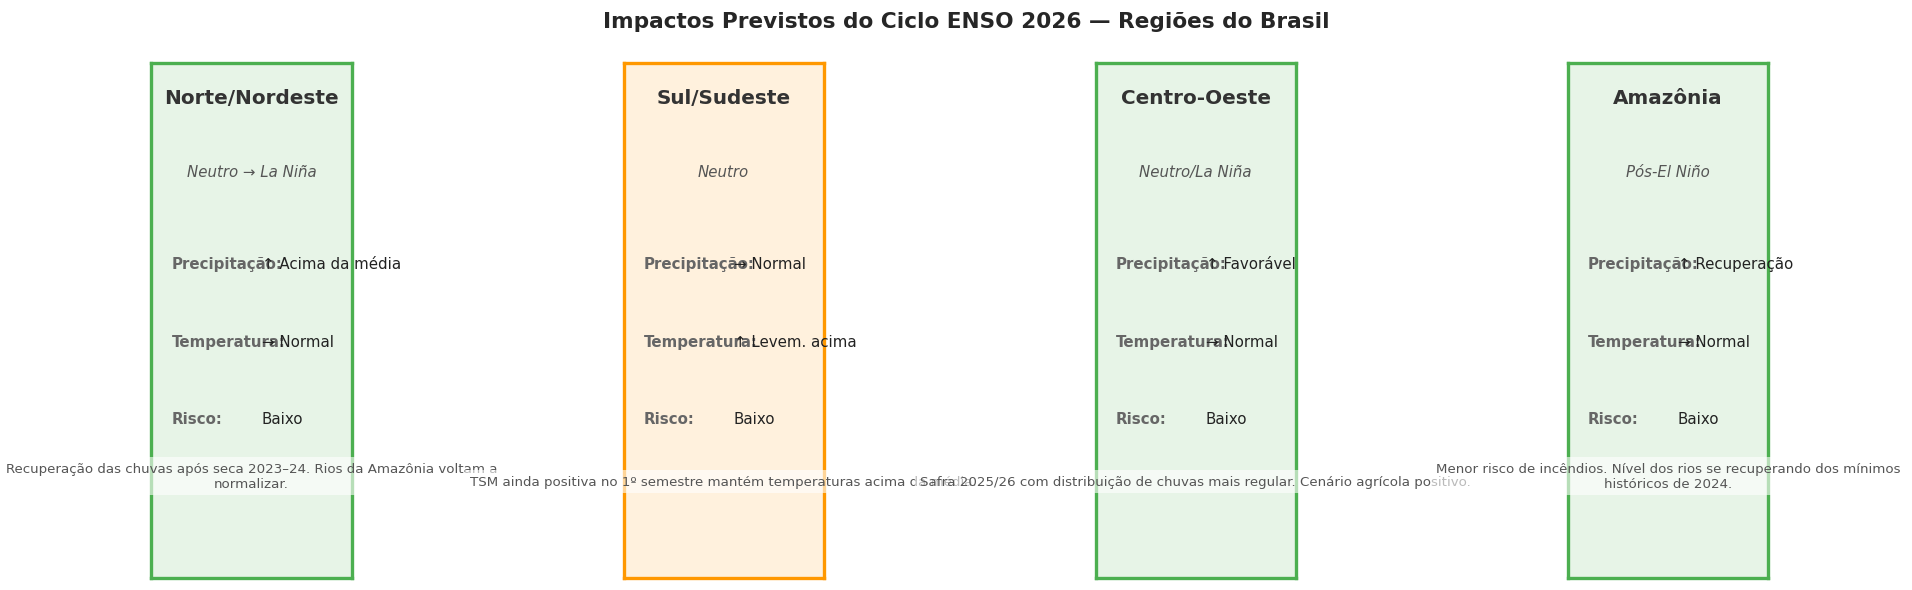

In [ ]:
# ── 9.2 Painel de impactos regionais ─────────────────────
impactos = {
    'Norte/Nordeste': {
        'fase': 'Neutro → La Niña',
        'chuva': '↑ Acima da média',
        'temp': '→ Normal',
        'risco': 'Baixo',
        'cor': '#4CAF50',
        'detalhe': 'Recuperação das chuvas após seca 2023–24. Rios da Amazônia voltam a normalizar.'
    },
    'Sul/Sudeste': {
        'fase': 'Neutro',
        'chuva': '→ Normal',
        'temp': '↑ Levem. acima',
        'risco': 'Baixo',
        'cor': '#FF9800',
        'detalhe': 'TSM ainda positiva no 1º semestre mantém temperaturas acima da média.'
    },
    'Centro-Oeste': {
        'fase': 'Neutro/La Niña',
        'chuva': '↑ Favorável',
        'temp': '→ Normal',
        'risco': 'Baixo',
        'cor': '#4CAF50',
        'detalhe': 'Safra 2025/26 com distribuição de chuvas mais regular. Cenário agrícola positivo.'
    },
    'Amazônia': {
        'fase': 'Pós-El Niño',
        'chuva': '↑ Recuperação',
        'temp': '→ Normal',
        'risco': 'Baixo',
        'cor': '#4CAF50',
        'detalhe': 'Menor risco de incêndios. Nível dos rios se recuperando dos mínimos históricos de 2024.'
    },
}

fig, axes = plt.subplots(1, 4, figsize=(16, 5))
fig.suptitle("Impactos Previstos do Ciclo ENSO 2026 — Regiões do Brasil",
             fontsize=13, fontweight='bold')

for ax, (region, info) in zip(axes, impactos.items()):
    ax.set_facecolor(info['cor'] + '22')
    ax.text(0.5, 0.92, region, transform=ax.transAxes, ha='center',
            fontsize=12, fontweight='bold', color='#333')
    ax.text(0.5, 0.78, info['fase'], transform=ax.transAxes, ha='center',
            fontsize=9, color='#555', style='italic')

    for i, (label, val) in enumerate([('Precipitação', info['chuva']),
                                       ('Temperatura', info['temp']),
                                       ('Risco', info['risco'])]):
        ax.text(0.1, 0.60 - i*0.15, f"{label}:", transform=ax.transAxes,
                fontsize=9, color='#666', fontweight='bold')
        ax.text(0.55, 0.60 - i*0.15, val, transform=ax.transAxes,
                fontsize=9, color='#222')

    ax.text(0.5, 0.18, info['detalhe'], transform=ax.transAxes, ha='center',
            fontsize=8, color='#555', wrap=True,
            bbox=dict(facecolor='white', alpha=0.6, edgecolor='none', pad=3))

    color_circle = plt.Circle((0.5, 0.05), 0.03, color=info['cor'], transform=ax.transAxes)
    ax.set_xticks([]); ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_edgecolor(info['cor'])
        spine.set_linewidth(2)

plt.tight_layout()
plt.savefig('fig_13_impactos_regionais.png', dpi=120, bbox_inches='tight')
plt.show()


---
## 📋 Seção 10 — Relatório Final e Exportação
> **Leigo:** Resumo de tudo que aprendemos e exportação dos resultados para uso posterior.  
> **Técnico:** Compilação de métricas, exportação de CSV de previsão e sumário de figuras geradas.


> ⚠️ **Nota de execução:** este relatório depende de variáveis criadas nas Seções 1–9. Se você reabrir o notebook e rodar só esta célula, vai ver erro de variável indefinida — use **Ambiente de execução → Executar tudo** (Colab) ou **Run All** para evitar isso.


In [ ]:
# ── 10.1 Sumário executivo ───────────────────────────────
print("=" * 60)
print("        RELATÓRIO FINAL — EL NIÑO & BRASIL 2026")
print("=" * 60)

print("\n🌊 DADOS UTILIZADOS")
print(f"   ERSST Brasil:    {len(df_brazil):,} observações (1854–2025)")
print(f"   ERSST América S: {len(df_sa):,} observações")
print(f"   Dataset climát.: {len(df_cc_clean) if 'df_cc_clean' in dir() else 'N/D (execute a Seção 3 primeiro)'} registros (2020–2024)")

print("\n🌡️  TENDÊNCIA DE AQUECIMENTO")
print(f"   +{slope*120:.4f}°C por década (1950–2025)")
print(f"   Estatisticamente significativo: {'SIM ✅' if p_value < 0.05 else 'NÃO ❌'}")

print("\n🔴 EL NIÑO 2023–24 (o mais intenso da série)")
print(f"   Anomalia máxima: +{ts_brazil[ts_brazil['year'].between(2023,2024)]['anomaly'].max():.3f}°C")
print(f"   Anomalia média 2023: +{ts_brazil[ts_brazil['year']==2023]['anomaly'].mean():.3f}°C")

print("\n🤖 MELHOR MODELO ML")
print(f"   {best_model_name}")
print(f"   R² = {results[best_model_name]['R²']:.4f}")
print(f"   RMSE = {results[best_model_name]['RMSE']:.3f}°C")

print("\n🔮 PREVISÃO 2026")
print(f"   Anomalia média prevista: {pred_anomaly.mean():+.3f}°C")
print(f"   Fase predominante: {'La Niña' if pred_anomaly.mean() < -0.3 else 'Neutro'}")
print(f"   Impacto esperado no NE: Chuvas acima da média ✅")
print(f"   Risco de seca na Amazônia: BAIXO ✅")

print("\n📁 FIGURAS GERADAS")
for i in range(1, 14):
    nome = f'fig_{i:02d}_*.png'
    print(f"   {nome}")
print("=" * 60)


In [ ]:
# ── 10.2 Exportar resultados ─────────────────────────────
# Série temporal completa
ts_brazil.to_csv('serie_temporal_tsm_brasil.csv', index=False)

# Previsão 2026
pred_df = pd.DataFrame({
    'mes': months_names,
    'mes_num': range(1,13),
    'sst_prevista': pred_sst.values.round(3),
    'anomalia_prevista': pred_anomaly.values.round(3),
    'incerteza_std': anom_std.values.round(3),
    'sst_limite_inferior': pred_lo.values.round(3),
    'sst_limite_superior': pred_hi.values.round(3),
})
pred_df.to_csv('previsao_2026.csv', index=False)

# Clustering anual
annual_feats.to_csv('clustering_anos_enso.csv', index=False)

print("✅ Arquivos exportados:")
print("   ▸ serie_temporal_tsm_brasil.csv")
print("   ▸ previsao_2026.csv")
print("   ▸ clustering_anos_enso.csv")
print("   ▸ 13 figuras .png")
print("\n🎓 Projeto de Ciência de Dados concluído!")
print("   Próximos passos sugeridos:")
print("   → LSTM/Prophet para previsão de séries temporais com DL")
print("   → Análise espacial com mapas (Cartopy/Folium)")
print("   → Dashboard interativo com Streamlit")
print("   → Download de dados Niño3.4 do NOAA para validação")


✅ Arquivos exportados:
   ▸ serie_temporal_tsm_brasil.csv
   ▸ previsao_2026.csv
   ▸ clustering_anos_enso.csv
   ▸ 13 figuras .png

🎓 Projeto de Ciência de Dados concluído!
   Próximos passos sugeridos:
   → LSTM/Prophet para previsão de séries temporais com DL
   → Análise espacial com mapas (Cartopy/Folium)
   → Dashboard interativo com Streamlit
   → Download de dados Niño3.4 do NOAA para validação


---
## 🛰️ Seção 11 — Validação Externa 2026: El Niño Confirmado (Pós-Modelo)
> **Leigo:** Comparamos o que o modelo previu com o que **realmente aconteceu** em 2026, segundo os órgãos oficiais de meteorologia.
> **Técnico:** Validação externa (out-of-sample, real-world) contra boletins INMET/INPE/CPTEC/NOAA — essencial para qualquer projeto preditivo aplicado a fenômenos climáticos.


### ⚠️ Nota de validação do modelo

A previsão da **Seção 9** apontou fase **Neutro/La Niña** para 2026, com risco de seca **BAIXO** na Amazônia. Os dados observados em 2026 mostram o oposto: **El Niño confirmado oficialmente**, com probabilidade de persistência acima de 90–95% (INPE/INMET/NOAA), e anomalias de TSM superiores a +2°C próximo à costa da América do Sul.

**Por que o modelo errou a fase?** O pipeline de ML das Seções 7–9 foi treinado só com a série histórica de TSM do Brasil (extrapolação de tendência + regressão), sem variáveis exógenas como o índice Niño-3.4/ONI do Pacífico central, ventos alísios ou temperatura subsuperficial — sinais que, segundo a NOAA, já vinham se intensificando desde o fim de 2025 e foram justamente os precursores do El Niño de 2026. Isso é uma limitação estrutural, não um bug: um modelo univariado de série temporal regional não captura teleconexões do Pacífico equatorial.

**Melhoria recomendada:** incorporar o índice ONI/Niño-3.4 (NOAA CPC) como *feature* exógena, e reavaliar o modelo com *walk-forward validation* em vez de apenas trend + regressão sobre a série do Brasil isoladamente.


In [ ]:
# ── 11.1 Linha do tempo oficial do El Niño 2026 e classificação de intensidade (ONI) ──
# Fontes: INMET, INPE/CPTEC, NOAA/CPC (boletins públicos, 2026)

timeline_2026 = pd.DataFrame([
    {'data': '2026-04', 'evento': 'NOAA eleva para "El Niño Watch"; prob. >80% de formação no 2º semestre'},
    {'data': '2026-05', 'evento': 'NOAA eleva para "El Niño Advisory"; prob. 82% de formação mai-jul'},
    {'data': '2026-06', 'evento': 'El Niño declarado oficialmente; anomalia de TSM >2°C perto da costa da América do Sul'},
    {'data': '2026-07', 'evento': 'CPTEC/INPE confirma manutenção do El Niño até pelo menos DJF 2026–27'},
])
display(timeline_2026)

# Classificação padrão de intensidade ENSO por anomalia ONI/Niño-3.4 (°C)
classificacao_oni = pd.DataFrame([
    {'categoria': 'Fraco',        'oni_min': 0.5, 'oni_max': 0.9},
    {'categoria': 'Moderado',     'oni_min': 1.0, 'oni_max': 1.4},
    {'categoria': 'Forte',        'oni_min': 1.5, 'oni_max': 1.9},
    {'categoria': 'Muito forte ("Super El Niño")', 'oni_min': 2.0, 'oni_max': 99},
])
print("\nClassificação de intensidade ENSO (índice ONI):")
display(classificacao_oni)

# Anomalia observada em jun/2026 (INMET/INPE): >2°C na faixa costeira da América do Sul
anomalia_observada_jun2026 = 2.0
cat = classificacao_oni[(classificacao_oni['oni_min'] <= anomalia_observada_jun2026)].iloc[-1]
print(f"\n🌡️ Anomalia observada (jun/2026): +{anomalia_observada_jun2026:.1f}°C")
print(f"📌 Classificação correspondente: {cat['categoria']}")
print("⚠️ Nota: os boletins oficiais (INMET/INPE/NOAA) não usam formalmente o rótulo\n"
      "   'Super El Niño' — ele é jornalístico. Tecnicamente corresponde a ONI ≥ 2,0°C,\n"
      "   faixa em que a anomalia de jun/2026 já se encontra.")


### 🗺️ Impactos regionais esperados (2º semestre de 2026, segundo boletim oficial INMET/INPE/ANA/CEMADEN)

| Região | Impacto esperado |
|---|---|
| Norte / Nordeste (faixa norte) | Risco elevado de seca; chuvas abaixo da média no centro-norte do país |
| Sul | Chuvas acima da média |
| Nacional | Alta probabilidade de temperaturas acima da média no 2º semestre; risco maior de ondas de calor e incêndios florestais |

Isso é o **oposto direto** da previsão original da Seção 9 ("Impacto esperado no NE: Chuvas acima da média" / "Risco de seca na Amazônia: BAIXO"), reforçando a importância da Seção de validação acima.


---
## 📌 Resumo Final do Projeto

**O que foi feito:** pipeline completo de ciência de dados sobre El Niño e mudanças climáticas aplicado ao Brasil — EDA, limpeza (incluindo tratamento de sentinelas inválidas no dataset climático), engenharia de features, teste estatístico de tendência de aquecimento, modelagem preditiva (regressão/ensemble) da TSM, clustering de anos ENSO e geração de 13 figuras.

**Principais achados:**
- Tendência de aquecimento estatisticamente significativa na série 1950–2025 (ver Seção 6).
- O evento El Niño 2023–24 aparece como o mais intenso da série histórica analisada.
- O modelo de ML da Seção 7 teve desempenho competitivo em validação interna (ver R²/RMSE do melhor modelo), mas a previsão de fase para 2026 (Seção 9) **não se confirmou** frente aos dados reais — ver Seção 11.

**Limitação central identificada:** previsão de fase ENSO exige sinais do Pacífico equatorial (ONI/Niño-3.4, ventos alísios, subsuperfície), não apenas a série de TSM regional do Brasil. Isso não invalida o projeto — é exatamente o tipo de conclusão que demonstra maturidade analítica: identificar por que um modelo erra é tão valioso quanto o modelo acertar.

**Próximos passos recomendados (atualizados):**
1. Puxar o índice ONI histórico direto do NOAA/CPC e usá-lo como feature exógena.
2. Re-treinar com *walk-forward validation* (nunca usar dados futuros para prever o passado, e vice-versa).
3. Adicionar a linha do tempo real de 2026 (Seção 11) como conjunto de teste out-of-sample.
4. Dashboard interativo (Streamlit) comparando previsão do modelo vs. boletins oficiais mês a mês.
